# Clustering of all data

Read in all necessary packages:

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
import random
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson

import scipy
import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_19428/1641485585.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
import omnipath

In [3]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [4]:
import decoupler as dc

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [5]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

### load TSS table to identify genes that switch TSS usage

In [6]:
TSS_table = pd.read_csv('../data/peter/20240118_Fig4_full_spliced_table_v2.csv', sep = '\t', index_col = 0)

In [7]:
TSS_table[[ 'name', 'Lin', 'rep', 'gene',
       'prom',  'prom_type' , 'biotype']].head(5)

,name,Lin,rep,gene,prom,prom_type,biotype
0,A330023F24Rik:1,ESC,1,A330023F24Rik,1,main_an,lncRNA
1,A330023F24Rik:2,ESC,1,A330023F24Rik,2,other,lncRNA
2,A330023F24Rik:1,PLU,1,A330023F24Rik,1,main_an,lncRNA
3,A330023F24Rik:2,PLU,1,A330023F24Rik,2,other,lncRNA
4,A330023F24Rik:1,ECT,1,A330023F24Rik,1,main_an,lncRNA


In [8]:
TSS_table_f1 = TSS_table[TSS_table['K4_state_avg_round'] == 1]

In [9]:
TSS_table_filtered = TSS_table_f1.drop_duplicates(subset=['name','Lin'], keep='first')

In [10]:
TSS_table_final = pd.DataFrame(TSS_table_filtered['name'].str.split(':', 
                                                 expand=True)).rename(columns={0:'gene',
                                                                               1:'promoter'})

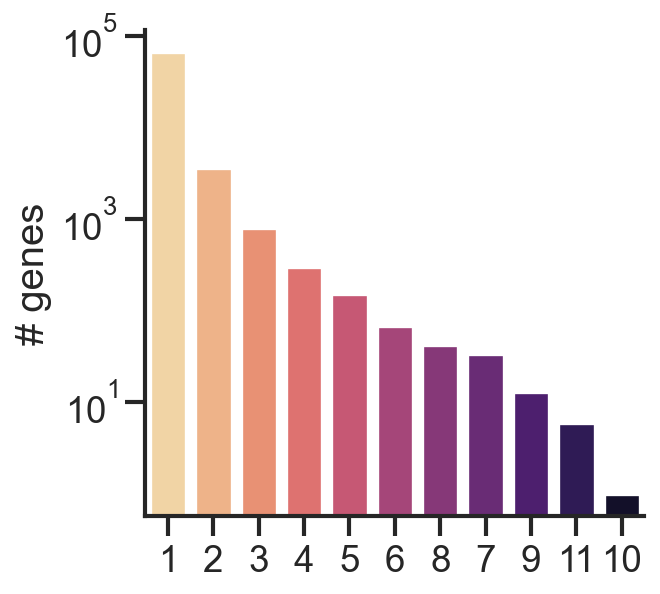

In [11]:
vals = pd.DataFrame(TSS_table_final['promoter'].value_counts())

sns.barplot(x = vals.index, y = vals['promoter'], palette = 'magma_r', )
sns.despine()
plt.ylabel('# genes')           
plt.yscale('log')
plt.legend([],frameon=False)

In [12]:
TSS_table_final = TSS_table_filtered[['Lin', 'gene','prom']]
TSS_table_final.head(2)

,Lin,gene,prom
0,ESC,A330023F24Rik,1
2,PLU,A330023F24Rik,1


In [13]:
numTSS = pd.DataFrame(TSS_table_final[['Lin','gene']].value_counts()).rename(columns = {0:'count'})
numTSS  = numTSS.reset_index()

In [14]:
genes = list(numTSS[(numTSS['count'] == 1) & (numTSS['Lin'] == 'ESC')]['gene'])
numTSS_ESC1 = numTSS[numTSS['gene'].isin(genes)]
genes = list(numTSS[(numTSS['count'] > 1) & (numTSS['Lin'] == 'ESC')]['gene'])
numTSS_ESCm = numTSS[numTSS['gene'].isin(genes)]

### load adata file and define groups for differential expression as 'diffx'

In [15]:
adata = sc.read_h5ad('../../2023/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

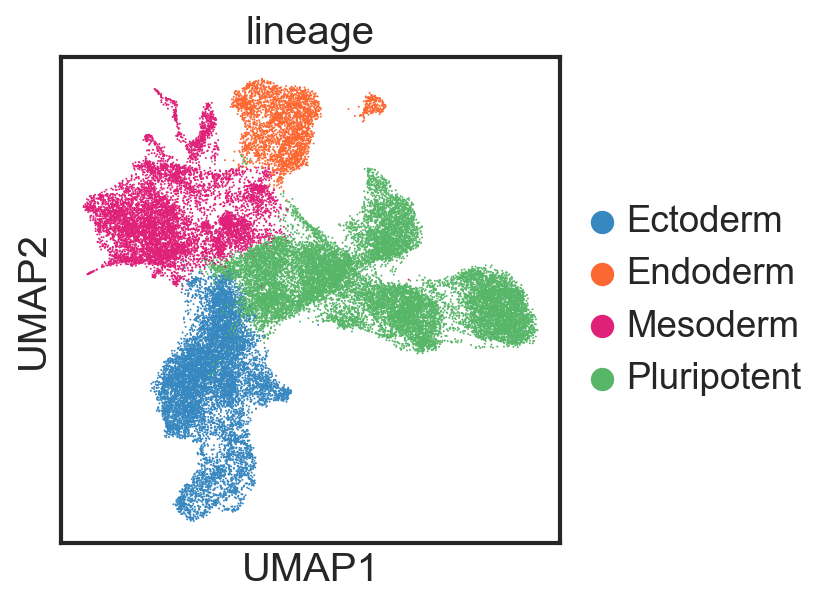

In [16]:
sc.pl.umap(adata, color = 'lineage')

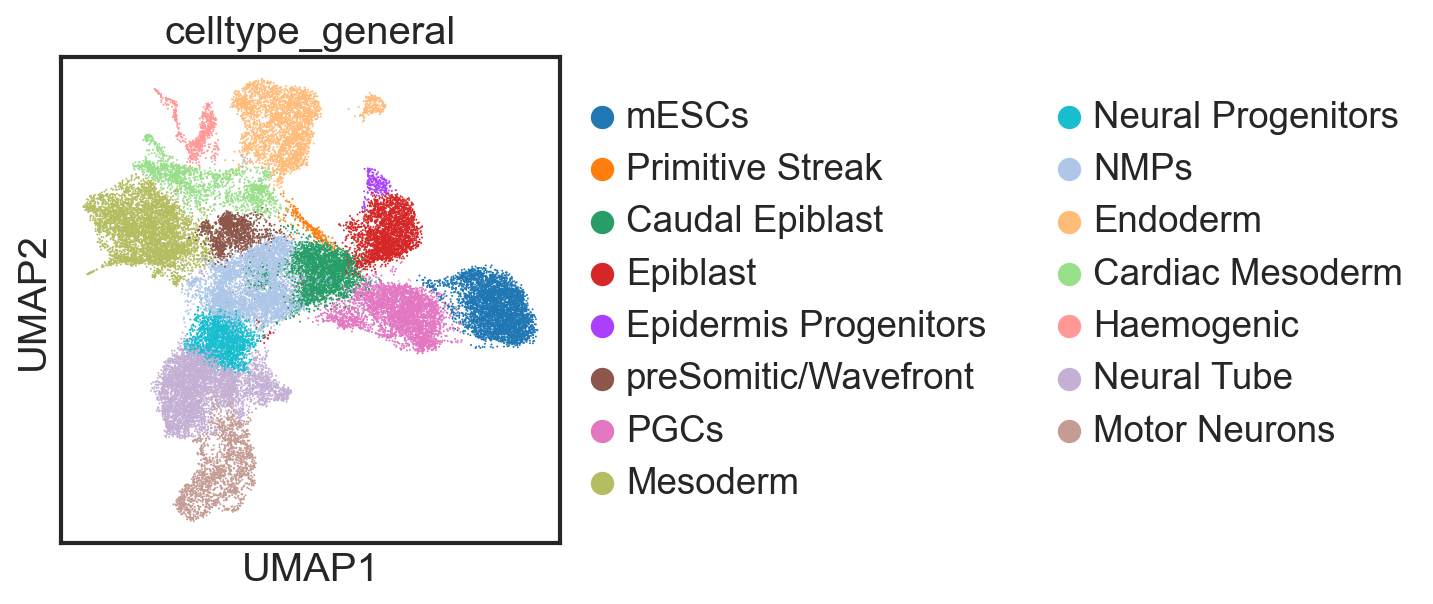

In [17]:
sc.pl.umap(adata, color = 'celltype_general')

In [18]:
dict_ct = {'Mesoderm':'MES',
 'Ectoderm':'ECT',
 'Endoderm':'END',
           'Pluripotent':'PLU'}


adata.obs['diffx'] = (
    adata.obs["lineage"]
    .map(lambda x: dict_ct.get(x, x))
    .astype("category")
)

In [19]:
adata.obs['diffx'] = adata.obs['diffx'].astype(str)

In [20]:
adata.obs.loc[list(adata[adata.obs['celltype'] == 'mESCs'].obs.index), 'diffx'] = 'ESC'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'PGCs'].obs.index), 'diffx'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epidermis Progenitors'].obs.index), 'diffx'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epiblast'].obs.index), 'diffx'] = 'x'


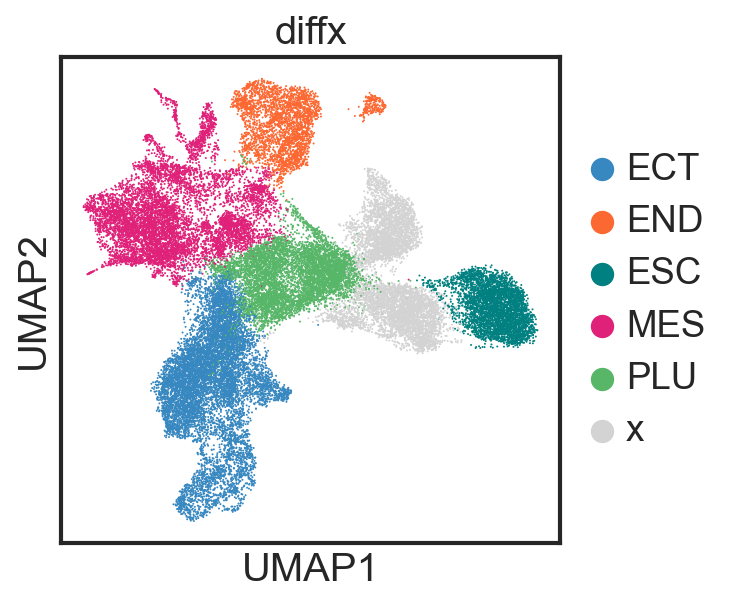

In [21]:
cols = ['#3787c0', '#fc6832', 'teal','#df2179', '#58b669','lightgrey']
sc.pl.umap(adata, color = 'diffx', palette = cols )

In [22]:
dict_ct = {'ECT':'DIFF',
 'MES':'DIFF',
 'END':'DIFF',
           'ESC':'ESC',
          'x':'x',
          'PLU':'x'}


adata.obs['diffx2'] = (
    adata.obs["diffx"]
    .map(lambda x: dict_ct.get(x, x))
    .astype("category")
)

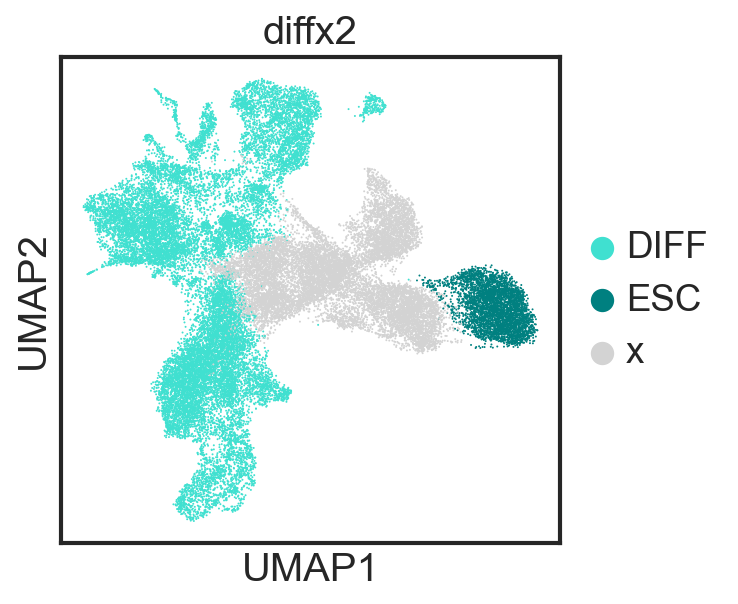

In [23]:
cols = ['turquoise', 'teal','lightgrey']
sc.pl.umap(adata, color = 'diffx2', palette = cols )

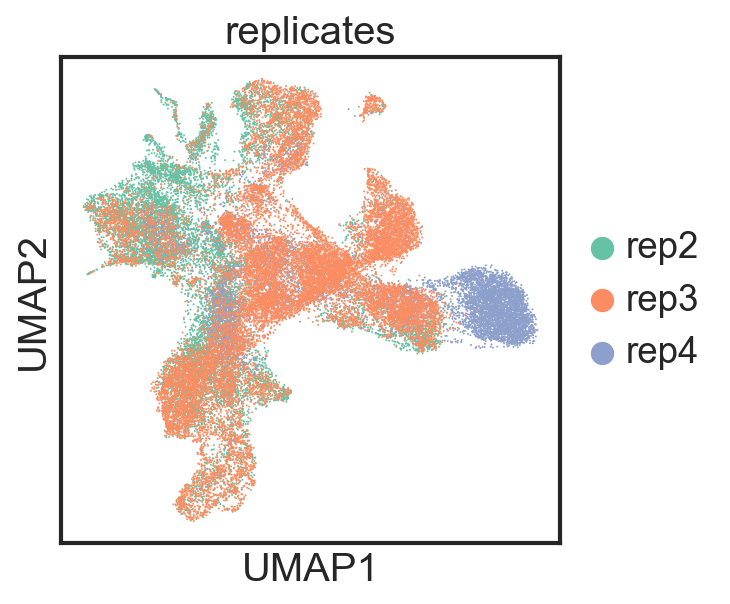

In [24]:
sc.pl.umap(adata, color = 'replicates', palette = sns.color_palette('Set2') )

In [25]:
sc.settings.verbosity = 2

## start decoupler
make pseudobulks, filter, run pydeseq

In [26]:
import decoupler as dc

Add back raw counts before pseudobulking - first group cells into pseudobulks, then normalise and log-transform counts again

In [27]:
adata.X = adata.layers['matrix']

In [28]:
# only keep cells annotated in diffx
adata_f = adata[adata.obs['diffx'] != 'x']

/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


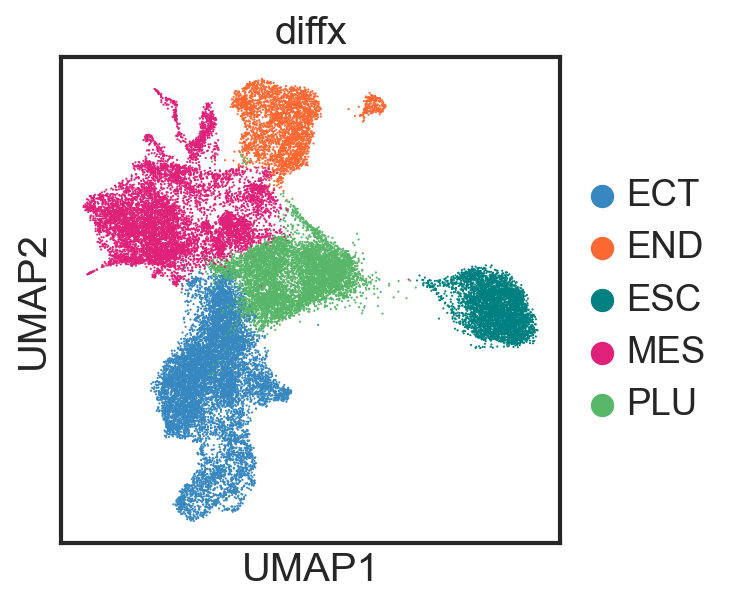

In [29]:
cols = ['#3787c0', '#fc6832', 'teal','#df2179', '#58b669','lightgrey']
sc.pl.umap(adata_f, color = 'diffx', palette = cols )

### define pseudobulks 

In [30]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata_f,
    groups_col='diffx',
    sample_col='replicates',
    mode='mean',
    min_cells=10,
    min_counts=0
)


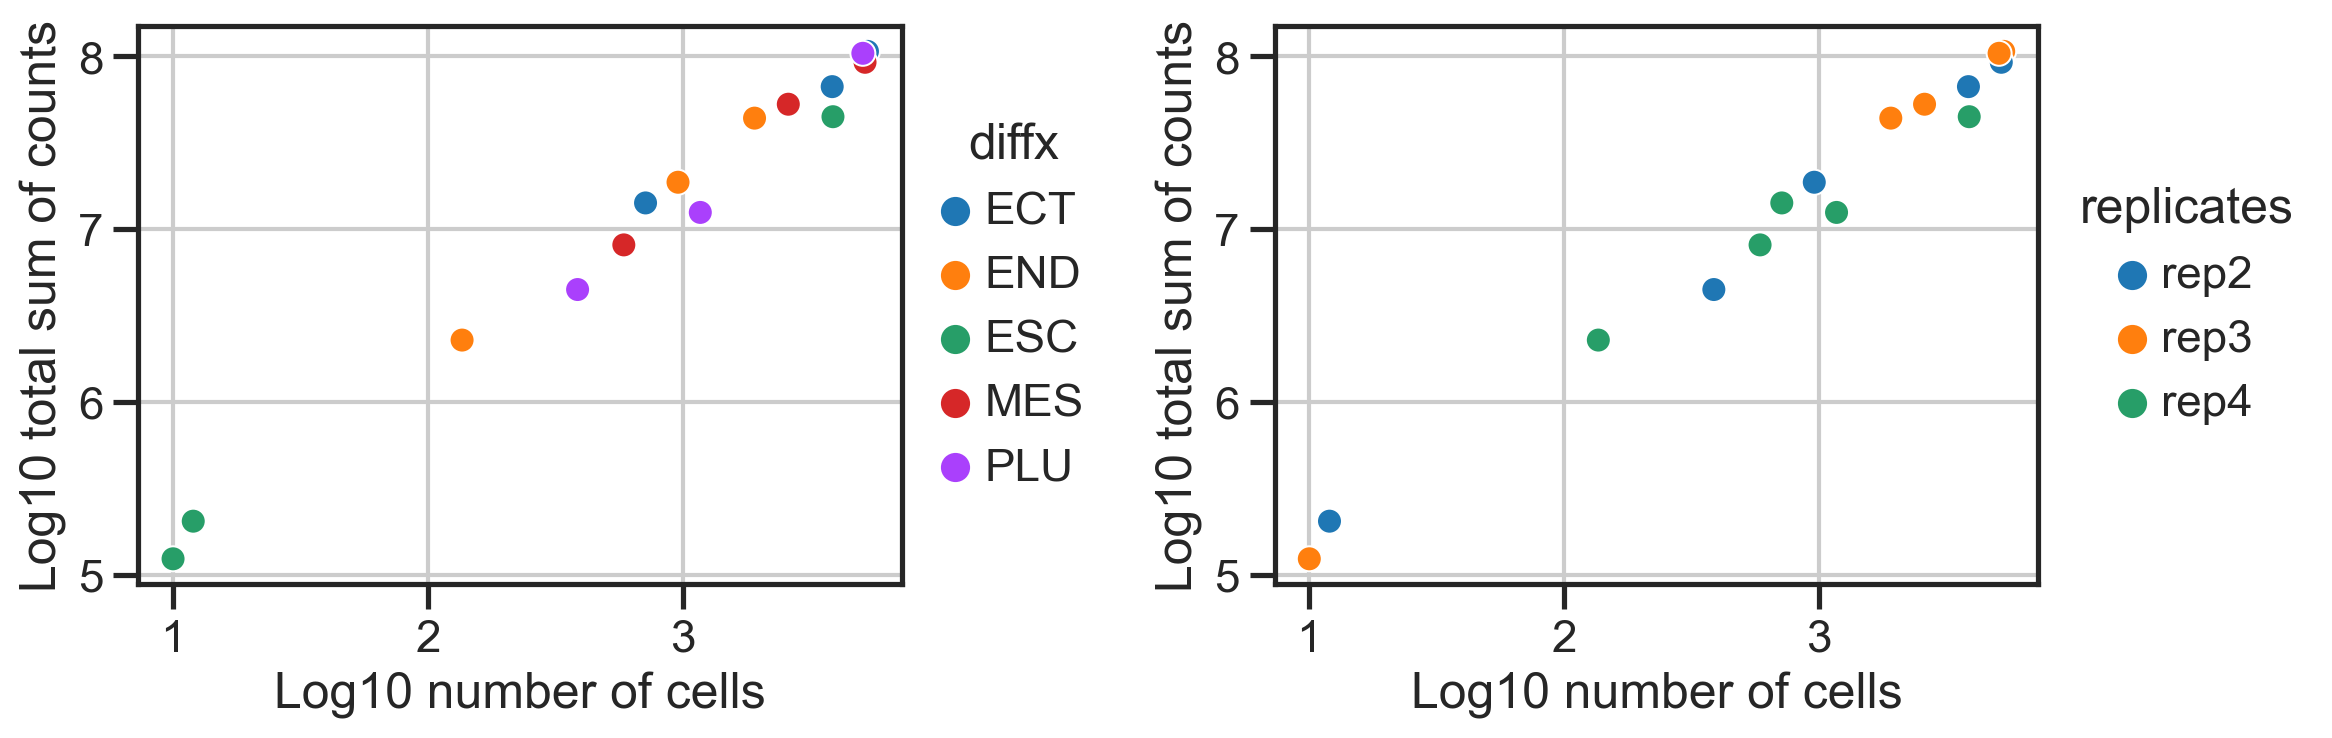

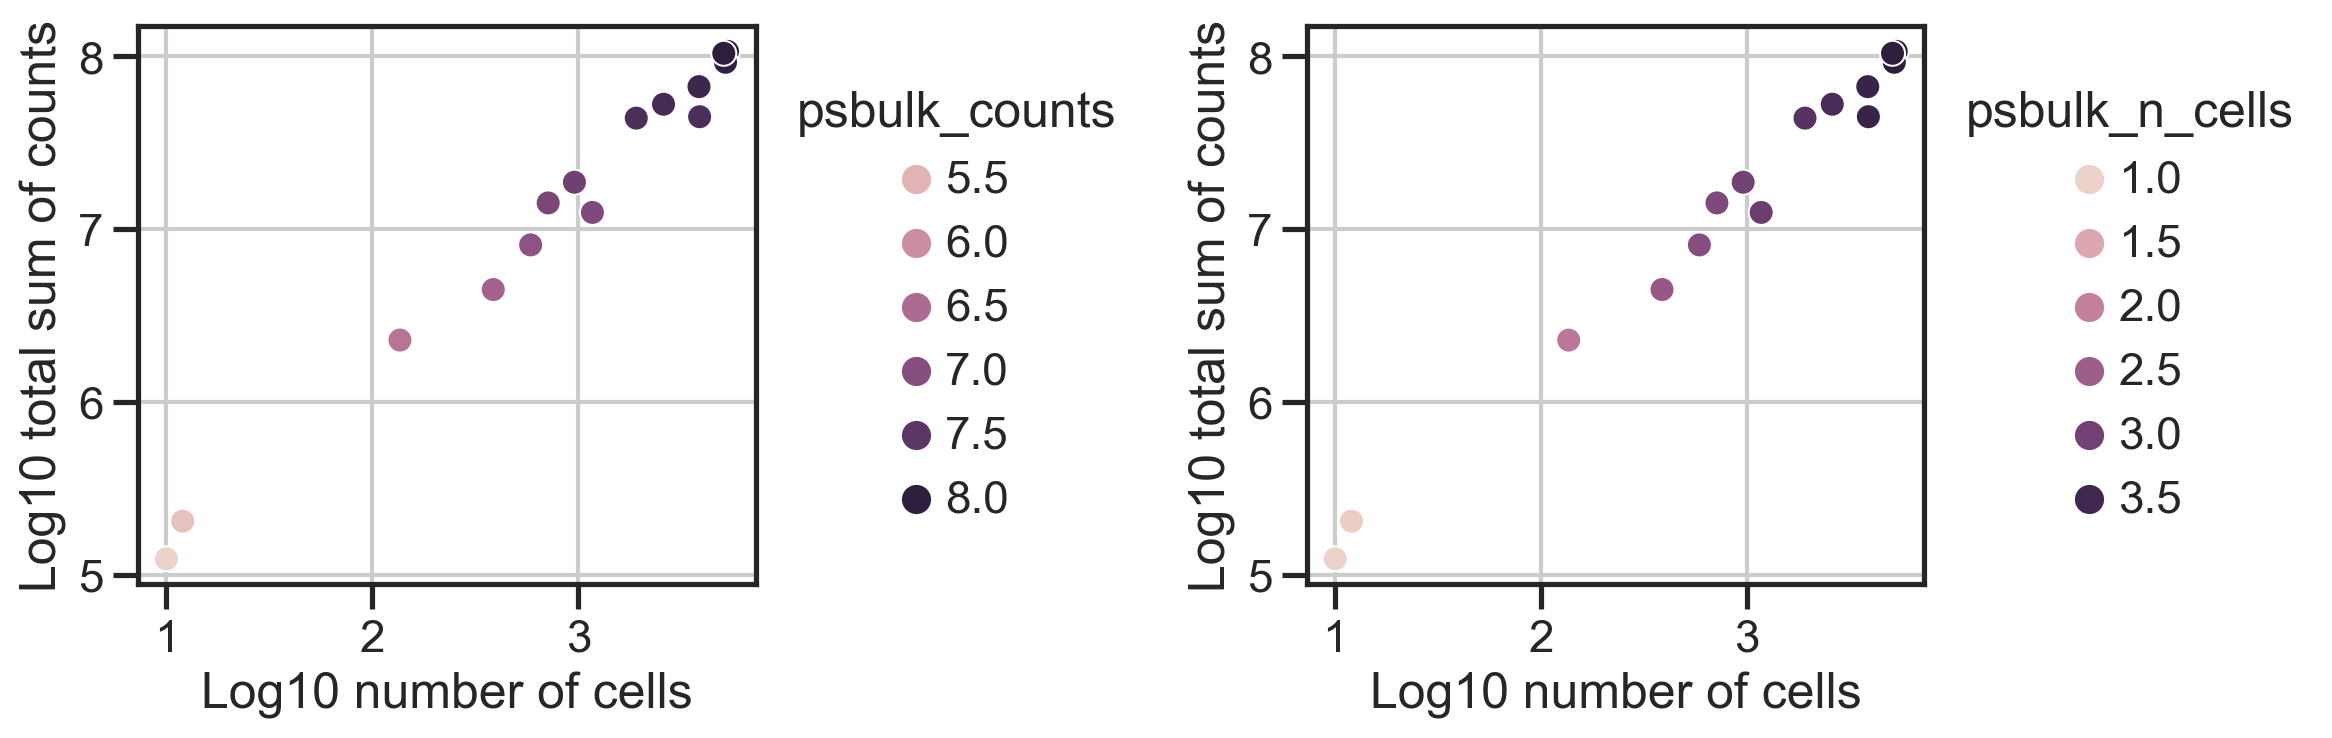

In [31]:
dc.plot_psbulk_samples(pdata, groupby=['diffx','replicates'],figsize=(12, 4))

dc.plot_psbulk_samples(pdata, groupby=['psbulk_counts','psbulk_n_cells'], figsize=(12, 4))



<AxesSubplot:ylabel='Count'>

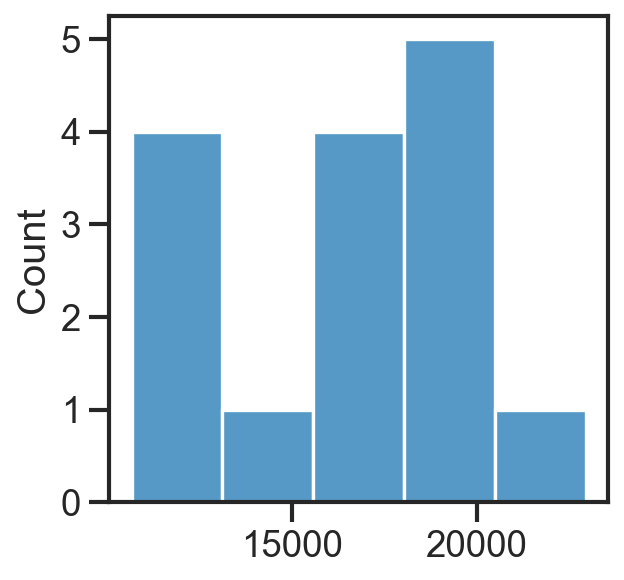

In [32]:
sns.histplot(pdata.obs['psbulk_counts']/pdata.obs['psbulk_n_cells'])

### filter pseudobulks

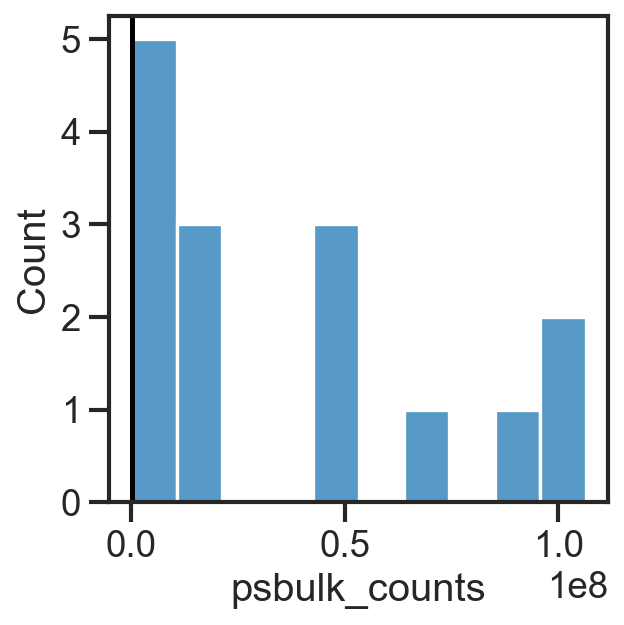

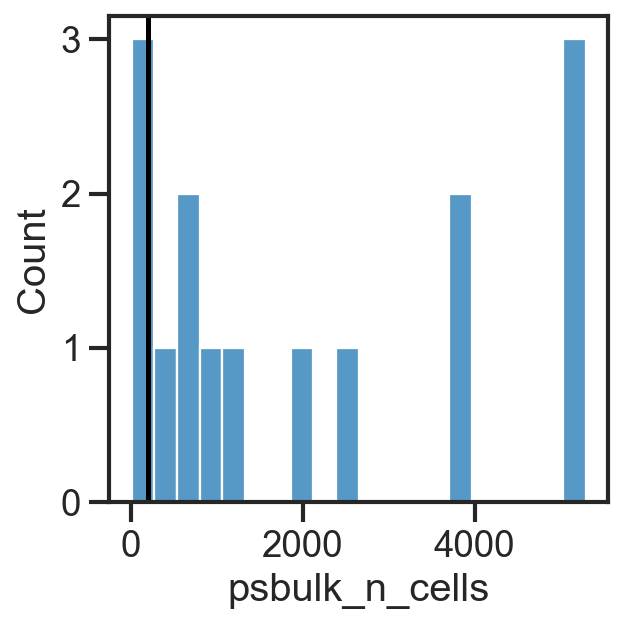

In [33]:
sns.histplot(pdata.obs['psbulk_counts'], bins = 10)
plt.axvline(200000, color = 'black')
plt.show()
sns.histplot(pdata.obs['psbulk_n_cells'], bins = 20)
plt.axvline(200, color = 'black')

In [34]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    adata_f,
    groups_col='diffx',
    sample_col='replicates',
    mode='sum',
    min_cells=200,
    min_counts=200000
)

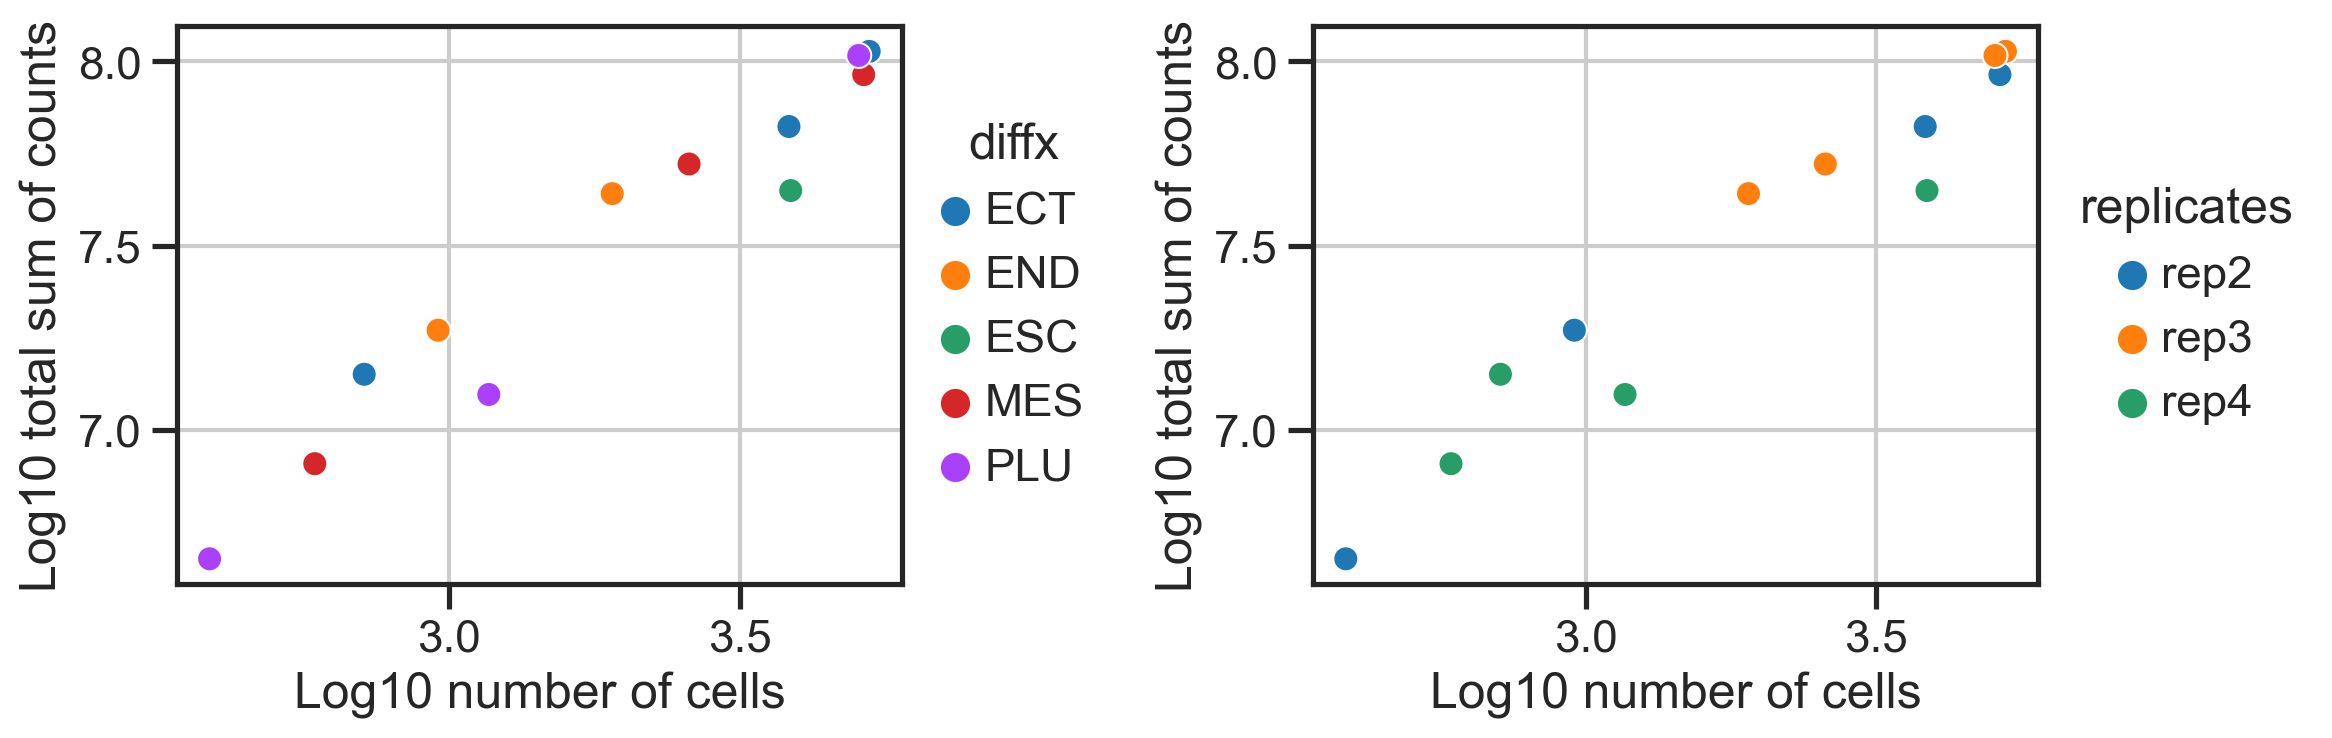

In [35]:
dc.plot_psbulk_samples(pdata, groupby=['diffx','replicates'],figsize=(12, 4))


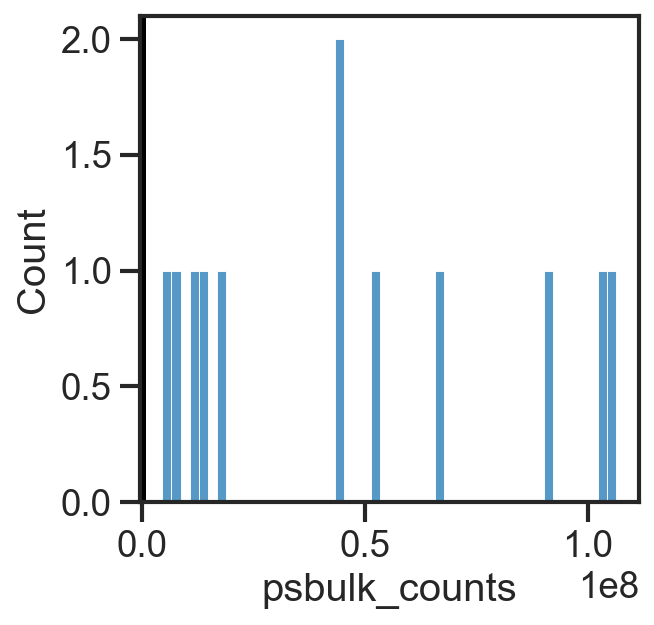

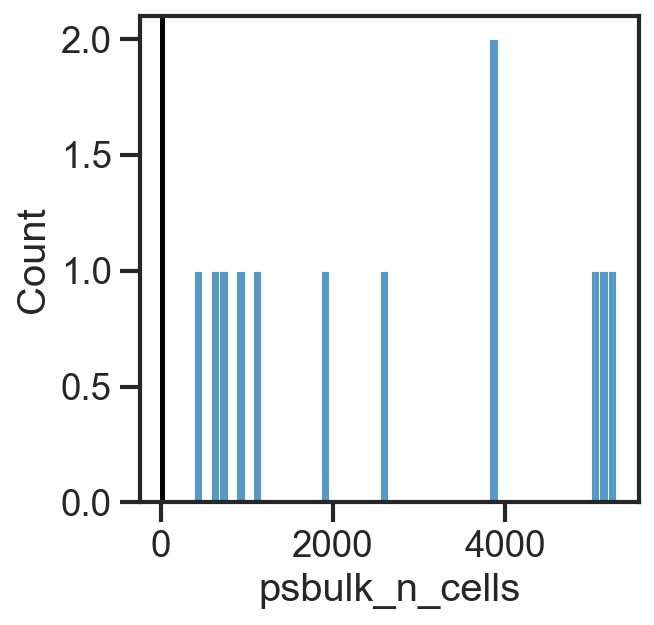

In [36]:
sns.histplot(pdata.obs['psbulk_counts'], bins = 50)
plt.axvline(200000, color = 'black')
plt.show()
sns.histplot(pdata.obs['psbulk_n_cells'], bins = 50)
plt.axvline(20, color = 'black')

### normalise and log-transform counts

In [37]:
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)


normalizing counts per cell
    finished (0:00:00)
computing PCA
    on highly variable genes
    with n_comps=11
    finished (0:00:00)


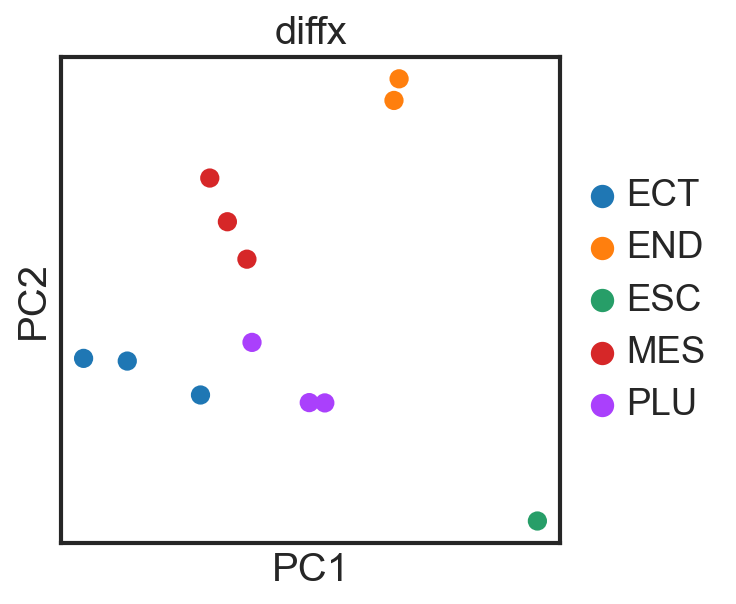

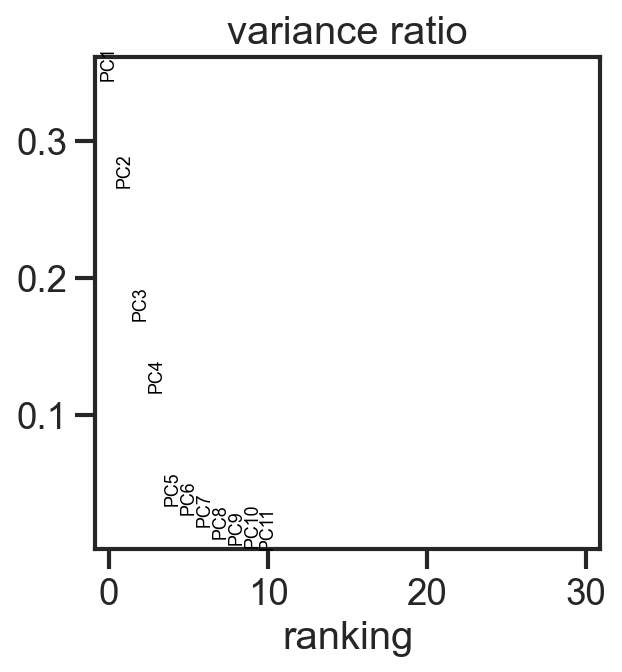

In [38]:
sc.pl.pca(pdata, color=['diffx'], ncols=3, size=300)
sc.pl.pca_variance_ratio(pdata)



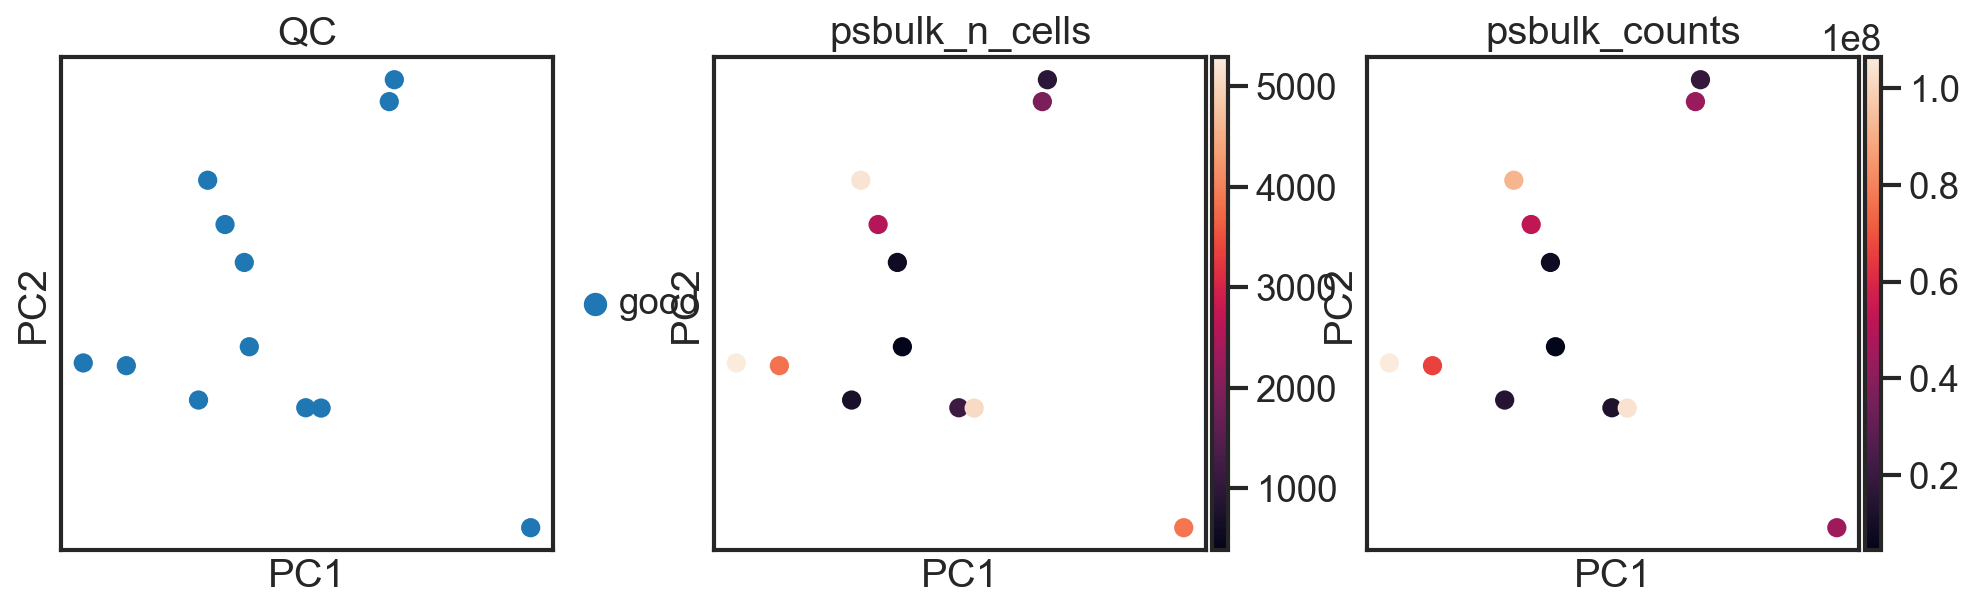

In [39]:
sc.pl.pca(pdata, color=['QC','psbulk_n_cells', 'psbulk_counts'], ncols=3, size=300)


### perform feature (gene) filtering

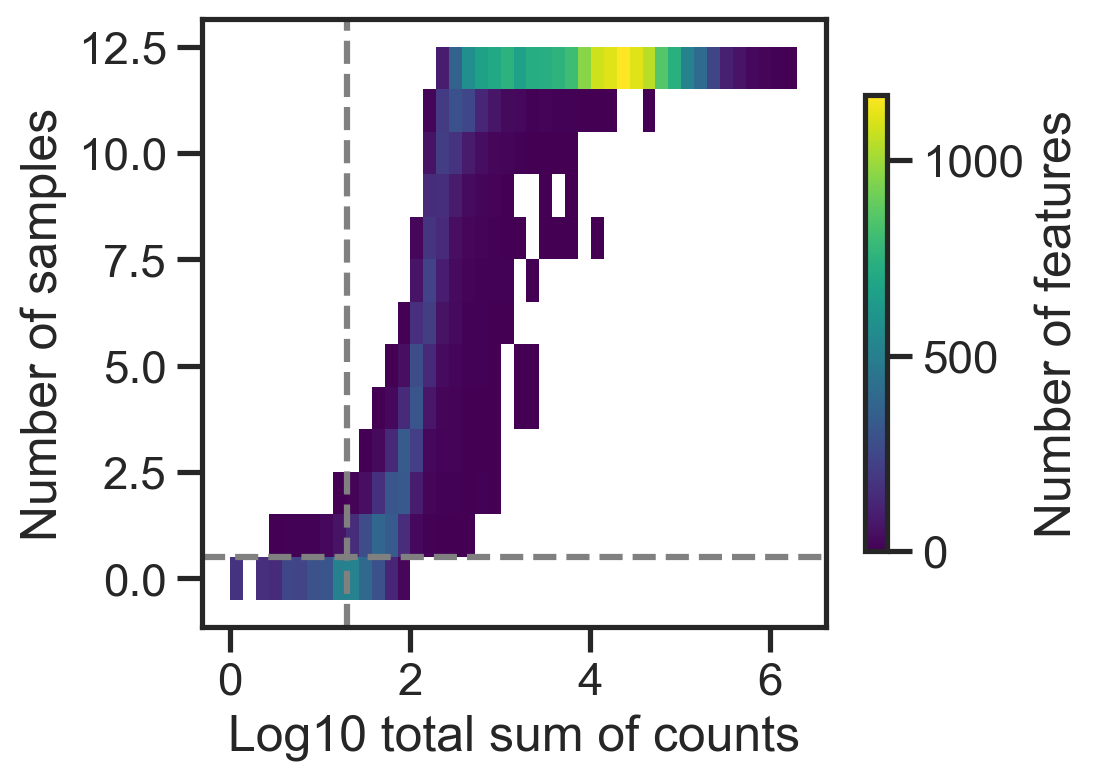

In [40]:
dc.plot_filter_by_expr(pdata, group='diffx', min_count=10, min_total_count=20)

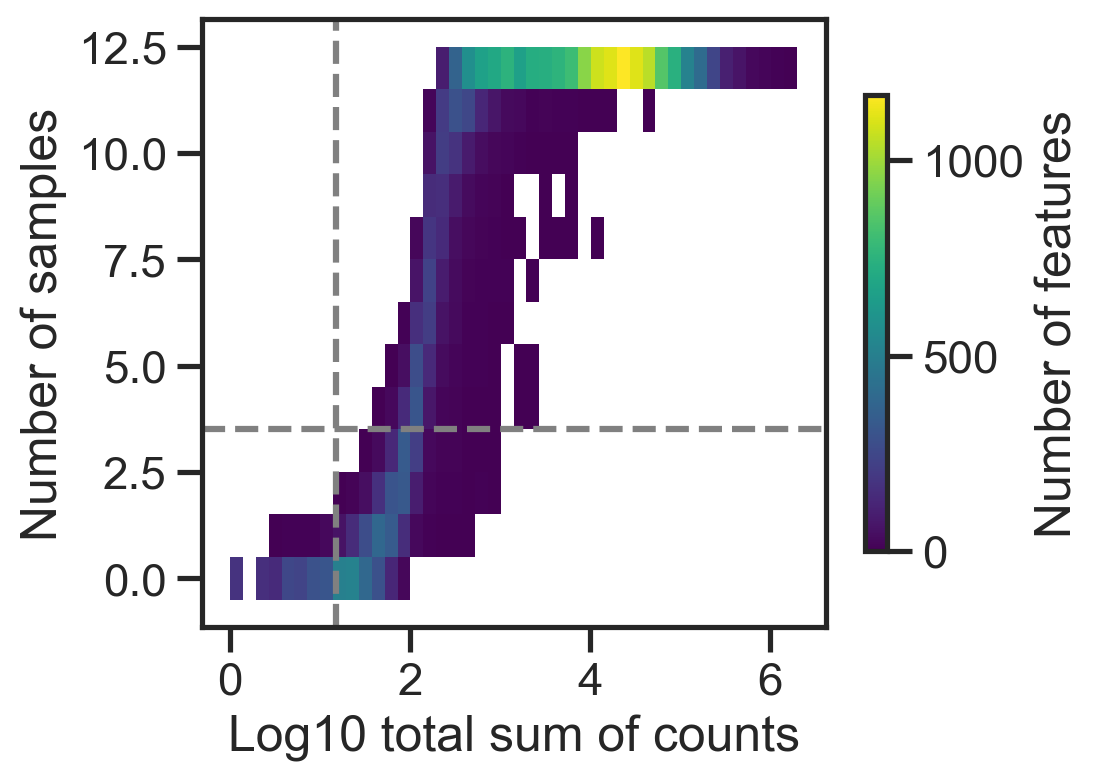

In [41]:
dc.plot_filter_by_expr(pdata, group='replicates', min_count=10, min_total_count=15)

In [42]:
pdata

AnnData object with n_obs × n_vars = 12 × 27332
    obs: 'replicates', 'lineage', 'QC', 'diffx', 'diffx2', 'psbulk_n_cells', 'psbulk_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'diffx_colors', 'QC_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [43]:
# Obtain genes that pass the thresholds
genes = dc.filter_by_expr(pdata, group='diffx', min_count=10, min_total_count=20)

# Filter by these genes
pdata = pdata[:, genes].copy()
pdata

AnnData object with n_obs × n_vars = 12 × 23837
    obs: 'replicates', 'lineage', 'QC', 'diffx', 'diffx2', 'psbulk_n_cells', 'psbulk_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'pca', 'diffx_colors', 'QC_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

### start DEseq differential analysis

In [44]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=1)
dds = DeseqDataSet(
    adata=pdata,
    design_factors='diffx',
    ref_level=['diffx', 'ESC'],
    refit_cooks=True,
    inference=inference,
)

In [45]:
# Compute LFCs
dds.deseq2()

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 322.62 seconds.

Fitting dispersion trend curve...
... done in 2.39 seconds.

Fitting MAP dispersions...
... done in 331.84 seconds.

Fitting LFCs...
... done in 27.91 seconds.

Refitting 0 outliers.



In [46]:
# Extract contrast between LINS vs ESC
stat_res_ect = DeseqStats(
    dds,
    contrast=["diffx", 'ESC','ECT' ],
    inference=inference,
)

stat_res_end = DeseqStats(
    dds,
    contrast=["diffx", 'ESC','END' ],
    inference=inference,
)

stat_res_mes = DeseqStats(
    dds,
    contrast=["diffx", 'ESC','MES' ],
    inference=inference,
)

stat_res_plu = DeseqStats(
    dds,
    contrast=["diffx", 'ESC','PLU' ],
    inference=inference,
)

In [47]:
# Compute Wald test
stat_res_ect.summary()
stat_res_end.summary()
stat_res_mes.summary()
stat_res_plu.summary()

Running Wald tests...
... done in 6.88 seconds.



Log2 fold change & Wald test p-value: diffx ESC vs ECT
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gene                                                                           
0610005C13Rik    30.535254        4.903346  0.653418  7.504144  6.183136e-14   
0610006L08Rik     9.678984        2.098593  0.895544  2.343371  1.911036e-02   
0610009B22Rik   327.874176        0.554868  0.197968  2.802809  5.065963e-03   
0610009E02Rik   149.369995       -0.104546  0.376307 -0.277820  7.811507e-01   
0610009L18Rik    81.240829       -0.292963  0.468660 -0.625106  5.319012e-01   
...                    ...             ...       ...       ...           ...   
Zyx            1929.471802       -3.201786  0.343900 -9.310212  1.275770e-20   
Zzef1          2240.473389       -0.752791  0.332722 -2.262526  2.366492e-02   
Zzz3           7000.982422       -0.087543  0.119835 -0.730529  4.650671e-01   
a               549.382507       -0.032869  0.393422 -0.083546  9

Running Wald tests...
... done in 7.06 seconds.



Log2 fold change & Wald test p-value: diffx ESC vs END
                  baseMean  log2FoldChange     lfcSE      stat        pvalue  \
Gene                                                                           
0610005C13Rik    30.535254        3.763442  0.692358  5.435687  5.458559e-08   
0610006L08Rik     9.678984        1.166756  0.953352  1.223846  2.210104e-01   
0610009B22Rik   327.874176        0.412034  0.212760  1.936609  5.279310e-02   
0610009E02Rik   149.369995        0.055008  0.403394  0.136363  8.915340e-01   
0610009L18Rik    81.240829       -0.908445  0.496528 -1.829593  6.731080e-02   
...                    ...             ...       ...       ...           ...   
Zyx            1929.471802       -2.921877  0.364331 -8.019838  1.058843e-15   
Zzef1          2240.473389       -0.806740  0.353043 -2.285107  2.230653e-02   
Zzz3           7000.982422       -0.107941  0.127310 -0.847864  3.965140e-01   
a               549.382507        0.070444  0.418374  0.168377  8

Running Wald tests...
... done in 6.79 seconds.



Log2 fold change & Wald test p-value: diffx ESC vs MES
                  baseMean  log2FoldChange     lfcSE       stat        pvalue  \
Gene                                                                            
0610005C13Rik    30.535254        4.603751  0.656628   7.011197  2.362875e-12   
0610006L08Rik     9.678984        1.686953  0.896129   1.882489  5.976959e-02   
0610009B22Rik   327.874176        0.501674  0.199567   2.513809  1.194352e-02   
0610009E02Rik   149.369995       -0.026959  0.378902  -0.071149  9.432790e-01   
0610009L18Rik    81.240829       -0.660963  0.469745  -1.407069  1.594068e-01   
...                    ...             ...       ...        ...           ...   
Zyx            1929.471802       -3.549456  0.344013 -10.317795  5.855208e-25   
Zzef1          2240.473389       -0.679660  0.332974  -2.041180  4.123295e-02   
Zzz3           7000.982422       -0.147934  0.120015  -1.232629  2.177143e-01   
a               549.382507       -0.279049  0.393854  

Running Wald tests...
... done in 6.89 seconds.



Log2 fold change & Wald test p-value: diffx ESC vs PLU
                  baseMean  log2FoldChange     lfcSE       stat        pvalue  \
Gene                                                                            
0610005C13Rik    30.535254        3.735747  0.659785   5.662066  1.495612e-08   
0610006L08Rik     9.678984        1.162666  0.912381   1.274321  2.025496e-01   
0610009B22Rik   327.874176        0.591496  0.205131   2.883500  3.932829e-03   
0610009E02Rik   149.369995        0.097137  0.386467   0.251345  8.015475e-01   
0610009L18Rik    81.240829       -0.257110  0.483076  -0.532234  5.945641e-01   
...                    ...             ...       ...        ...           ...   
Zyx            1929.471802       -3.861034  0.344428 -11.209979  3.642793e-29   
Zzef1          2240.473389       -0.400435  0.333909  -1.199236  2.304360e-01   
Zzz3           7000.982422        0.013648  0.120697   0.113075  9.099711e-01   
a               549.382507        0.082946  0.396826  

In [48]:
# Extract results
results_df_ect = stat_res_ect.results_df
results_df_end = stat_res_end.results_df
results_df_mes = stat_res_mes.results_df
results_df_plu = stat_res_plu.results_df
results_df_ect.head(2)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gene,,,,,,
0610005C13Rik,30.535254,4.903346,0.653418,7.504144,6.183136e-14,8.382405e-13
0610006L08Rik,9.678984,2.098593,0.895544,2.343371,1.911036e-02,4.444352e-02


/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


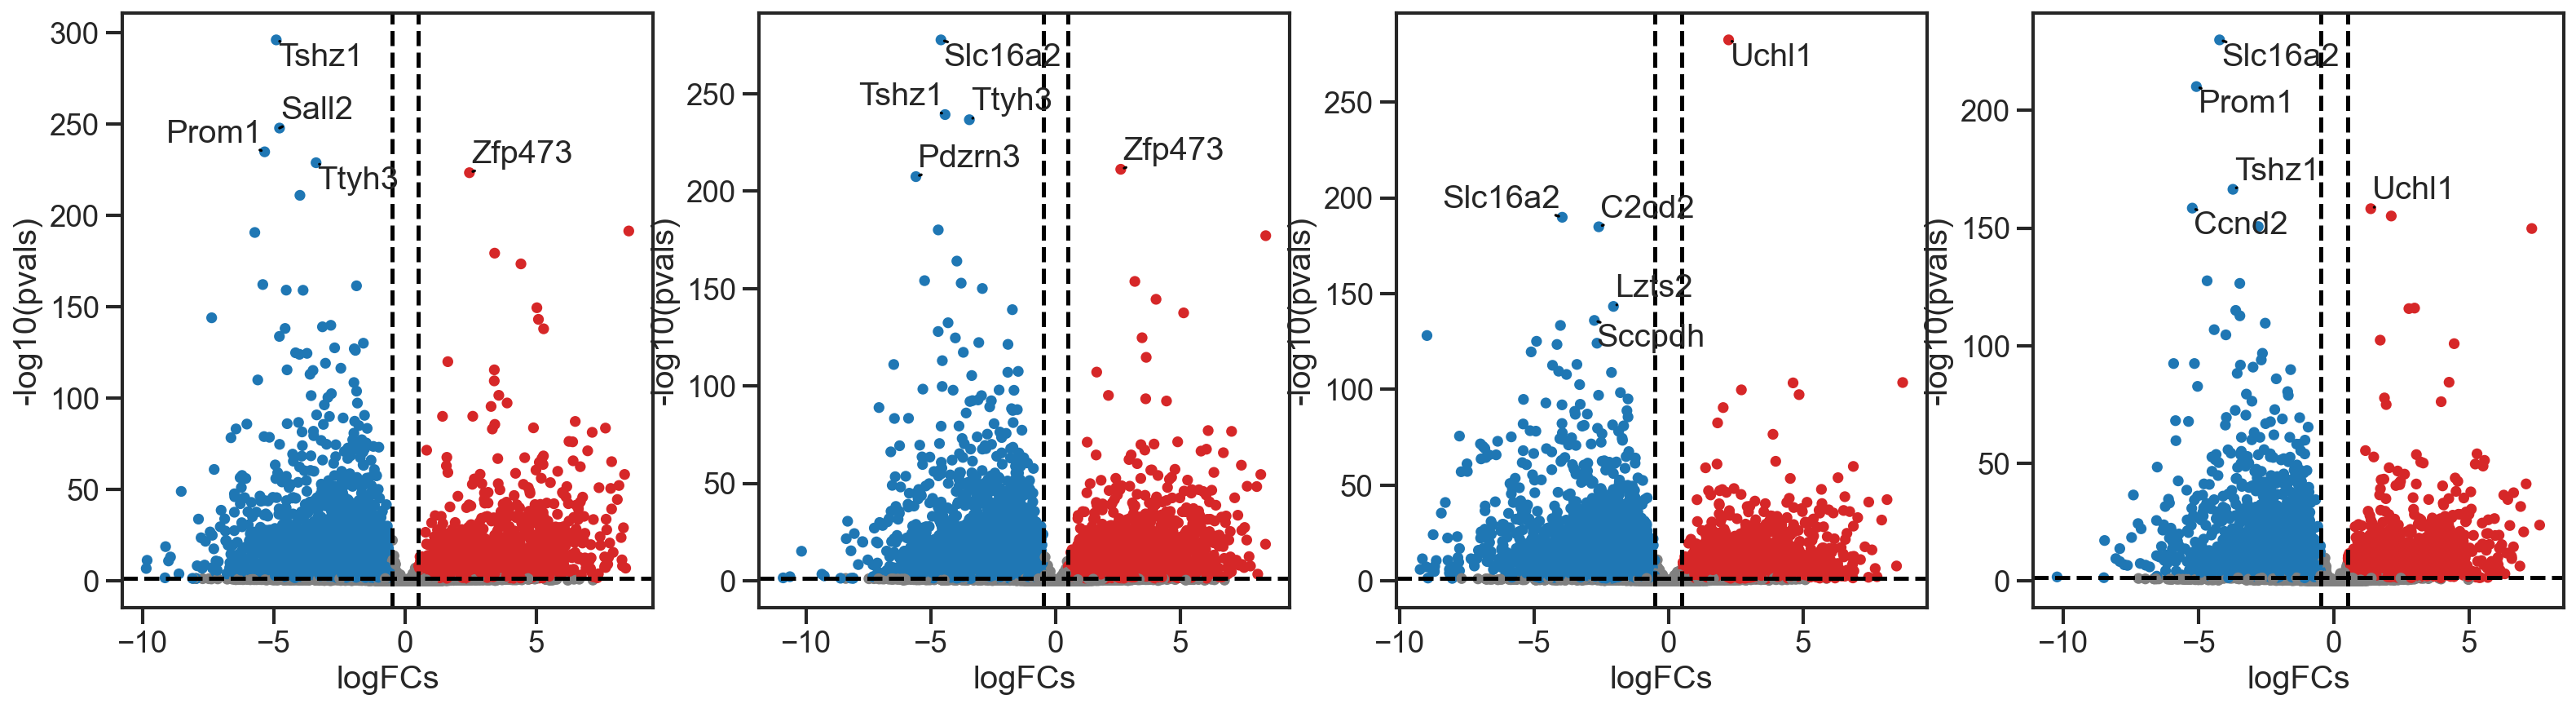

In [49]:
fig,ax=plt.subplots(1,4,figsize = (24,6))

dc.plot_volcano_df(
    results_df_ect,
    x='log2FoldChange',
    y='padj',
    top=5,
    ax=ax[0],
    figsize=(4,4)
)

dc.plot_volcano_df(
    results_df_mes,
    x='log2FoldChange',
    y='padj',
    top=5,
    ax=ax[1],
    figsize=(4,4)
)

dc.plot_volcano_df(
    results_df_end,
    x='log2FoldChange',
    y='padj',
    top=5,
    ax=ax[2],
    figsize=(4,4)
)

dc.plot_volcano_df(
    results_df_plu,
    x='log2FoldChange',
    y='padj',
    top=5,
    ax=ax[3],
    figsize=(4,4)
)

## Gene regulatory network analysis

In [52]:
def add_TSS_info(df, lin):
     #1 in ESCs, 1 in LIN
    ESC1LIN1 = list(numTSS_ESC1[(numTSS_ESC1['Lin'] == lin) & (numTSS_ESC1['count'] == 1)]['gene'])
    # 1 in ESCs, multiple in LIN
    ESC1LINm = list(numTSS_ESC1[(numTSS_ESC1['Lin'] == lin) & (numTSS_ESC1['count'] != 1)]['gene'])
    # multiple in ESCs, 1 in LIN
    ESCmLIN1 = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == lin) & (numTSS_ESCm['count'] == 1)]['gene'])
    # multiple in ESCs, multiple in LIN
    ESCmLINm = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == lin) & (numTSS_ESCm['count'] != 1)]['gene'])
    
    df['TSS'] = 0
    df.loc[(list(set(df.index) & set(ESC1LIN1))), 'TSS'] = '1_to_1'
    df.loc[(list(set(df.index) & set(ESC1LINm))), 'TSS'] = '1_to_m'
    df.loc[(list(set(df.index) & set(ESCmLIN1))), 'TSS'] = 'm_to_1'
    df.loc[(list(set(df.index) & set(ESCmLINm))), 'TSS'] = 'm_to_m'
    
    return df


In [53]:
results_df_ect = add_TSS_info(results_df_ect, 'ECT')
results_df_mes = add_TSS_info(results_df_mes, 'MES')
results_df_end = add_TSS_info(results_df_end, 'END')
results_df_plu = add_TSS_info(results_df_plu, 'PLU')

In [55]:
# Retrieve CollecTRI gene regulatory network
collectri = dc.get_collectri(organism='mouse', split_complexes=False)
#collectri = pd.read_csv('20240229_GRN_all.csv',index_col=0)

collectri.head(2)

,source,target,weight,PMID
0,Myc,Tert,1,10022128;10491298;10606235;10637317;10723141;1...
1,Spi1,Bglap,1,10022617


In [56]:
mat = results_df_ect[['stat']].rename(columns={'stat': 'ECT'})
mat['MES'] = results_df_mes[['stat']]
mat['END'] = results_df_end[['stat']]
mat['PLU'] = results_df_plu[['stat']]
mat = mat.T
mat

Gene,0610005C13Rik,0610006L08Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610010K14Rik,0610012G03Rik,0610025J13Rik,0610030E20Rik,0610031O16Rik,...,Zwint,Zxdb,Zxdc,Zyg11a,Zyg11b,Zyx,Zzef1,Zzz3,a,ccdc198
ECT,7.504144,2.343371,2.802809,-0.277820,-0.625106,-0.700096,2.419387,0.662724,-7.602804,1.769424,...,-3.060230,-5.994990,-2.708560,7.129135,-16.601845,-9.310212,-2.262526,-0.730529,-0.083546,0.777597
MES,7.011197,1.882489,2.513809,-0.071149,-1.407069,0.466027,1.261982,1.430177,-5.808577,2.320317,...,-3.486297,-5.508620,-1.267207,5.902189,-19.022715,-10.317795,-2.041180,-1.232629,-0.708509,1.833380
END,5.435687,1.223846,1.936609,0.136363,-1.829593,0.031838,-0.678010,0.493808,-4.937675,1.612982,...,-5.644752,-7.569387,-3.703635,5.661006,-20.015604,-8.019838,-2.285107,-0.847864,0.168377,-3.279372
PLU,5.662066,1.274321,2.883500,0.251345,-0.532234,-0.659136,2.757297,0.575170,-4.524754,1.116760,...,-2.899599,-4.281502,-1.979272,2.253691,-12.801277,-11.209979,-1.199236,0.113075,0.209023,1.177351


In [57]:
# Infer pathway activities with ulm
tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
tf_acts

,Abl1,Ahr,Ahrr,Aire,Apex1,Ar,Arid1a,Arid3a,Arid3b,Arid4a,...,Znf148,Znf219,Znf24,Znf263,Znf335,Znf354c,Znf382,Znf436,Znf76,Znf804a
ECT,-1.448594,1.342315,-0.764857,1.100057,2.886275,-1.136428,-1.335289,1.450730,-1.123719,0.981398,...,-0.632594,-1.245786,-0.476468,0.700799,1.063290,-1.911022,-0.113818,-1.283862,1.002472,-0.673614
MES,-0.738479,1.137539,-1.117363,-0.245616,3.029225,-2.552743,-1.829703,2.301341,-1.084046,0.258589,...,-1.387053,-1.329259,1.274523,0.699284,0.629363,-3.475108,0.532958,-1.072094,1.155288,0.069282
END,-0.726264,1.053663,0.423128,-0.815349,3.175459,-2.732130,-2.583386,3.317348,-0.535234,0.419352,...,-1.360641,-0.688197,0.889364,1.251103,1.168814,-3.568480,-0.474514,-0.253156,1.026675,0.189009
PLU,-1.974253,1.060199,-0.729886,0.653377,2.443733,-1.303878,-2.737208,1.482050,-1.023873,0.734917,...,-1.303252,-1.437574,0.386779,-0.323229,1.249059,-2.604208,0.075753,-0.758199,1.543804,-0.489625


In [58]:
results_df_ect['p_log'] = -np.log10(results_df_ect['padj'])
results_df_mes['p_log'] = -np.log10(results_df_mes['padj'])
results_df_end['p_log'] = -np.log10(results_df_end['padj'])
results_df_plu['p_log'] = -np.log10(results_df_plu['padj'])

/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/m.blotenburg/miniconda3/envs/multiconda2/lib/python3.8/site-packages/pandas/core/arraylike.py:397: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


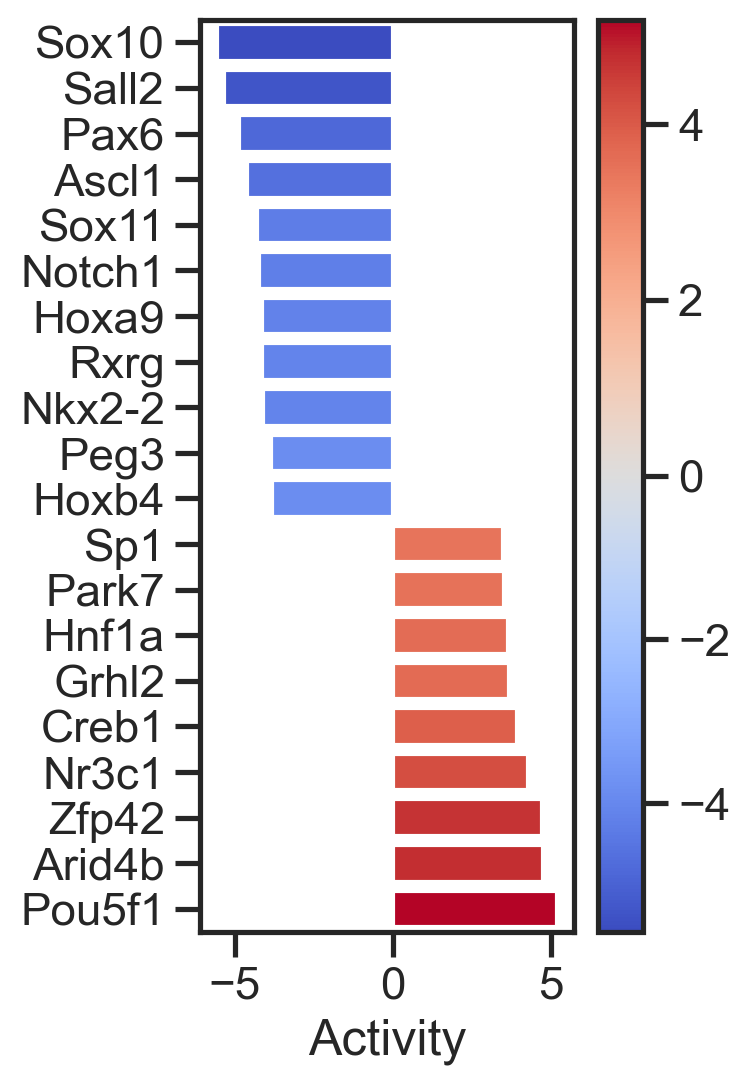

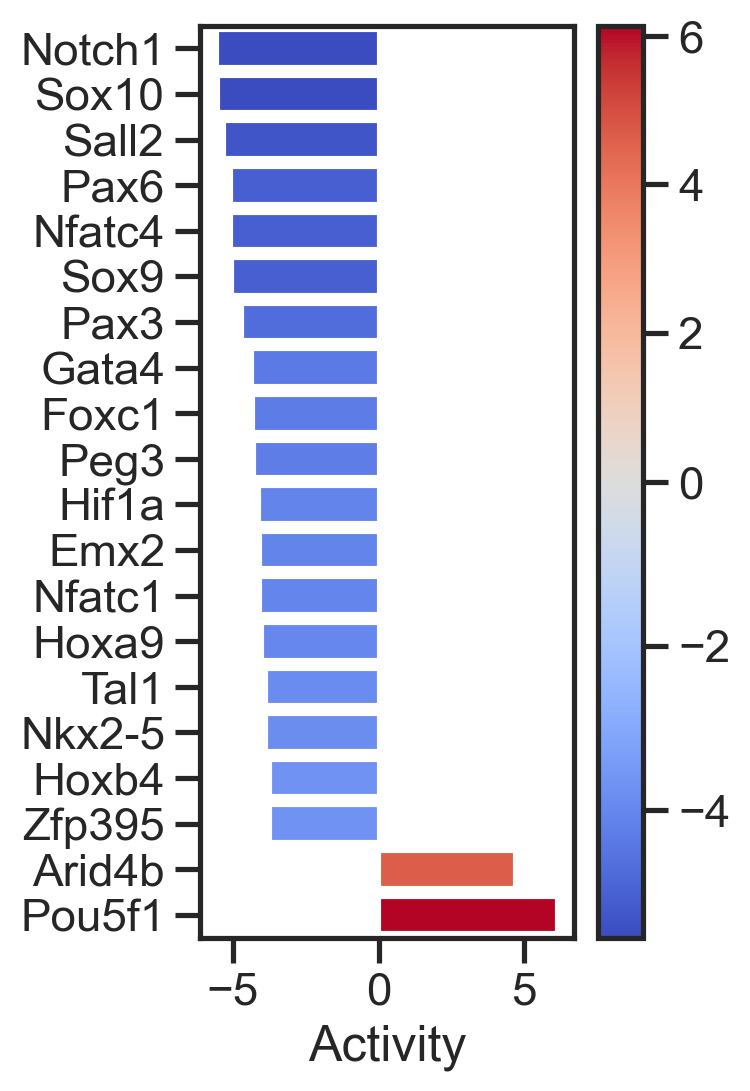

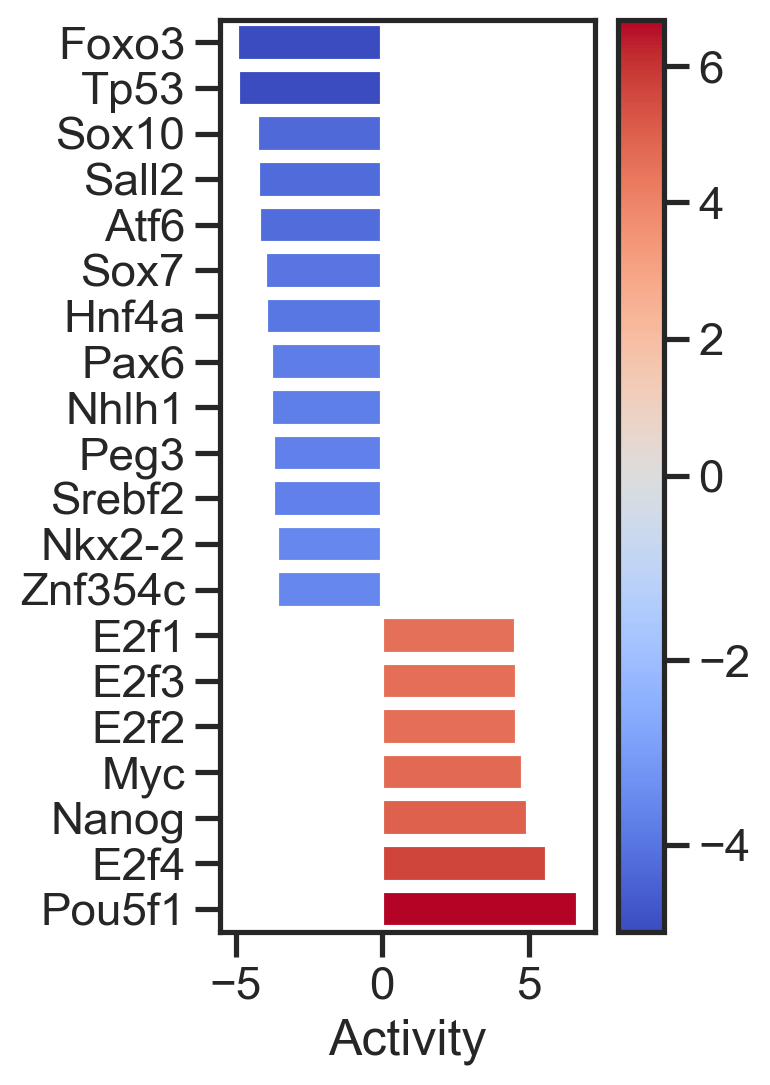

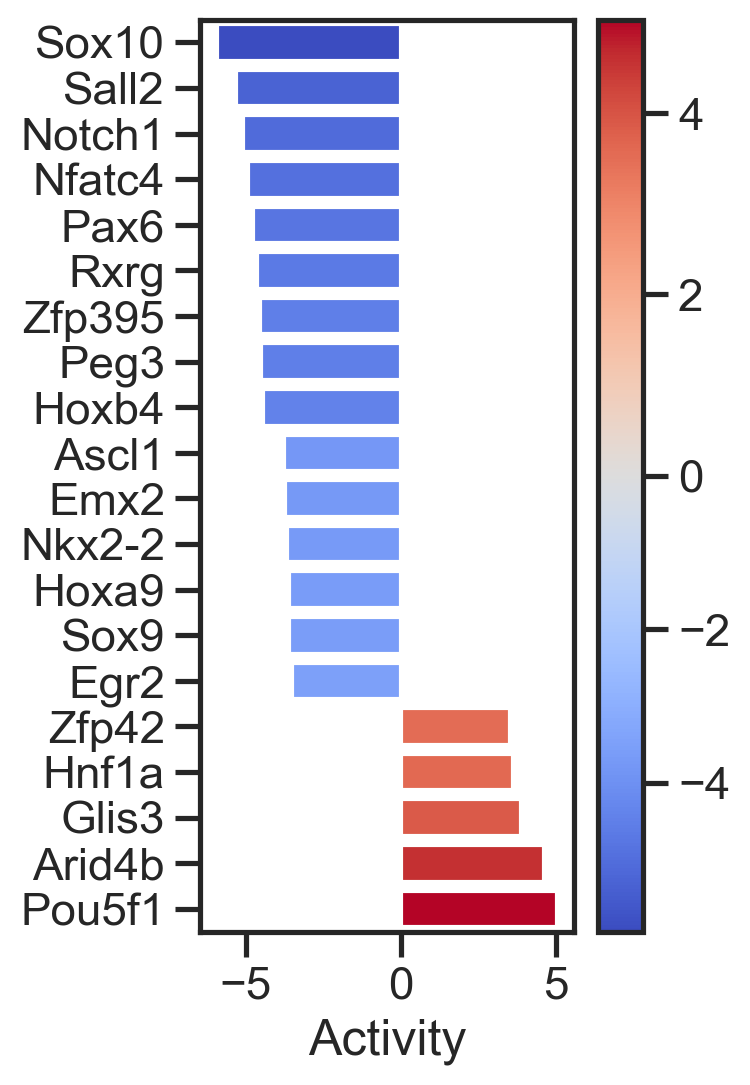

In [59]:
dc.plot_barplot(
    acts=tf_acts,contrast='ECT',
    top=20,vertical=True,figsize=(3, 6))

dc.plot_barplot(
    acts=tf_acts,contrast='MES',
    top=20,vertical=True,figsize=(3, 6))

dc.plot_barplot(
    acts=tf_acts,contrast='END',
    top=20,vertical=True,figsize=(3, 6))

dc.plot_barplot(
    acts=tf_acts,contrast='PLU',
    top=20,vertical=True,figsize=(3, 6))

In [60]:
def makeTFplots(df,lin):
    for genelist in ['1_to_1','m_to_1','m_to_m']:
        tf_acts, tf_pvals = dc.run_ulm(mat=mat[df[df['TSS'] == genelist].index], net=collectri)
        print(lin,genelist)
        dc.plot_barplot(
        acts=tf_acts,contrast=lin,
        top=20,vertical=True,figsize=(3, 6))
        plt.savefig(str(lin)+'-'+str(genelist)+'.png', bbox_inches="tight")
        plt.show()



ECT 1_to_1


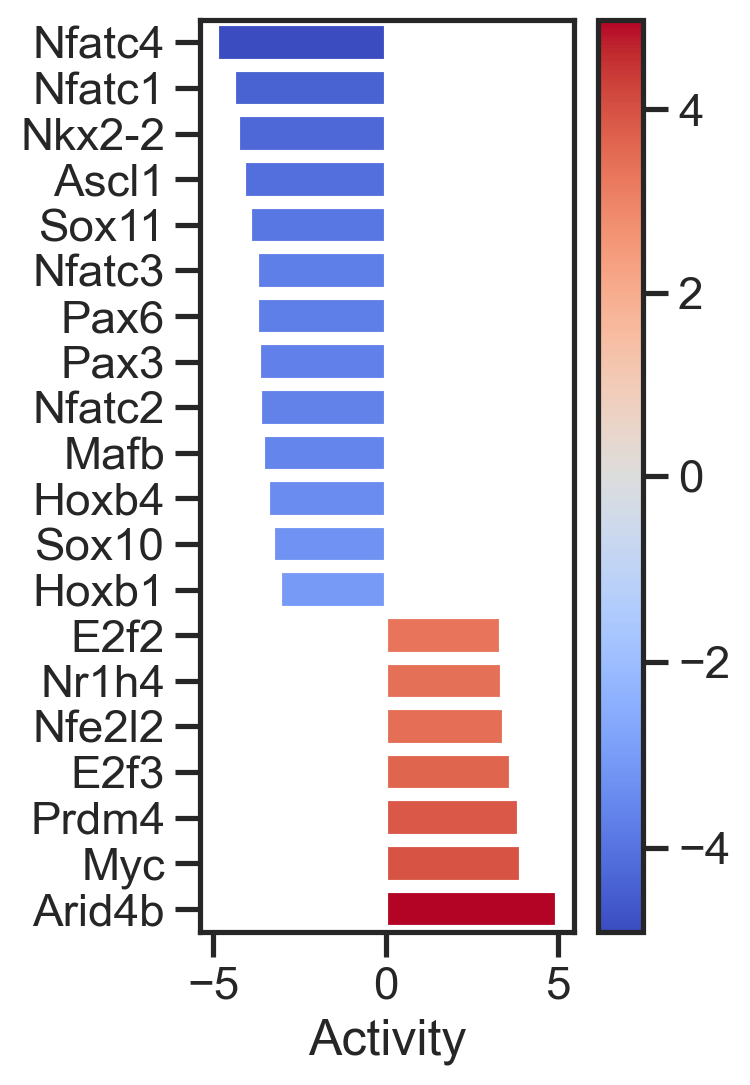

ECT m_to_1


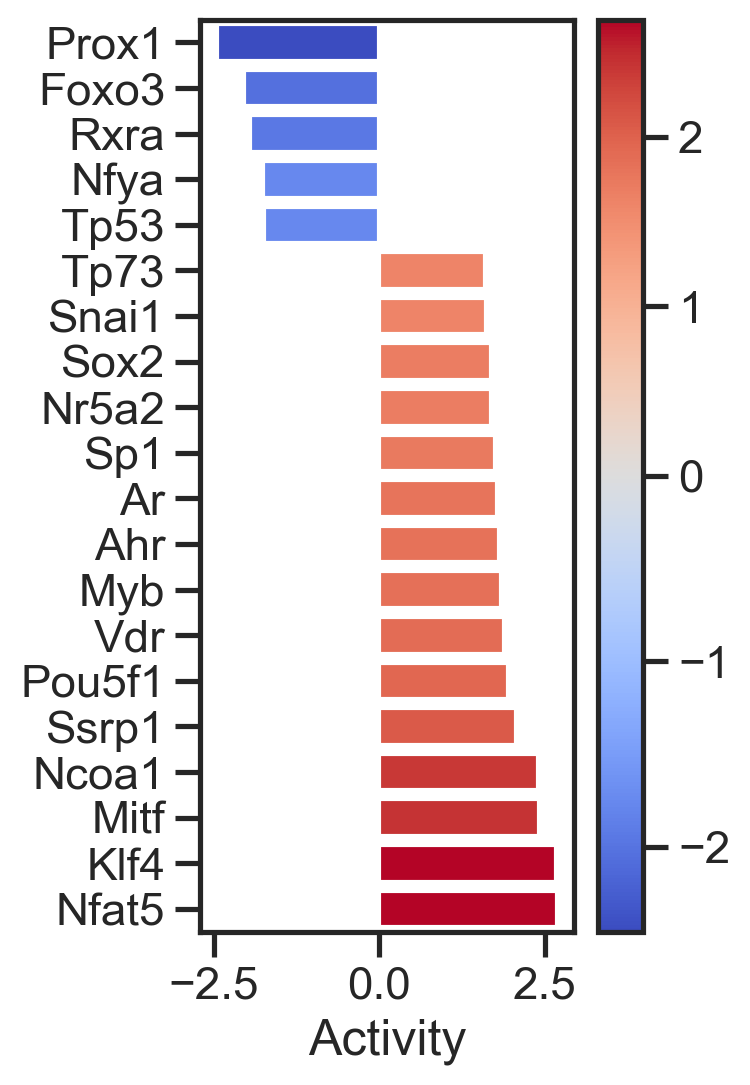

ECT m_to_m


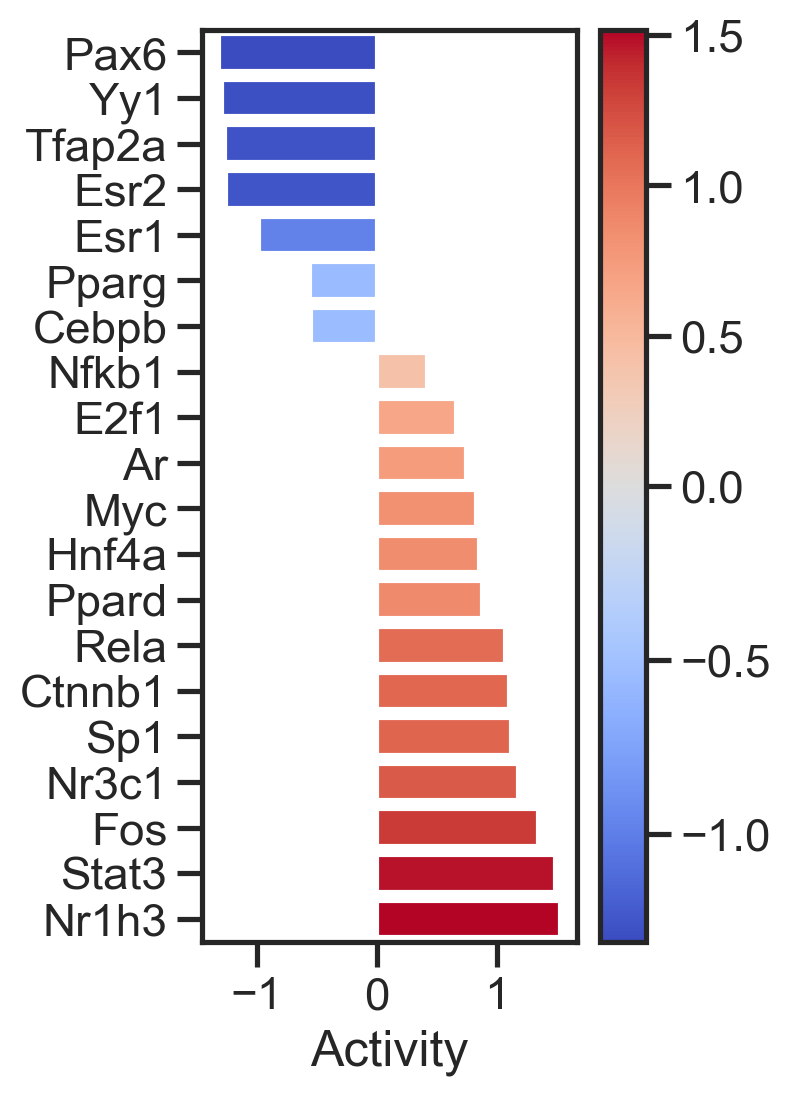

MES 1_to_1


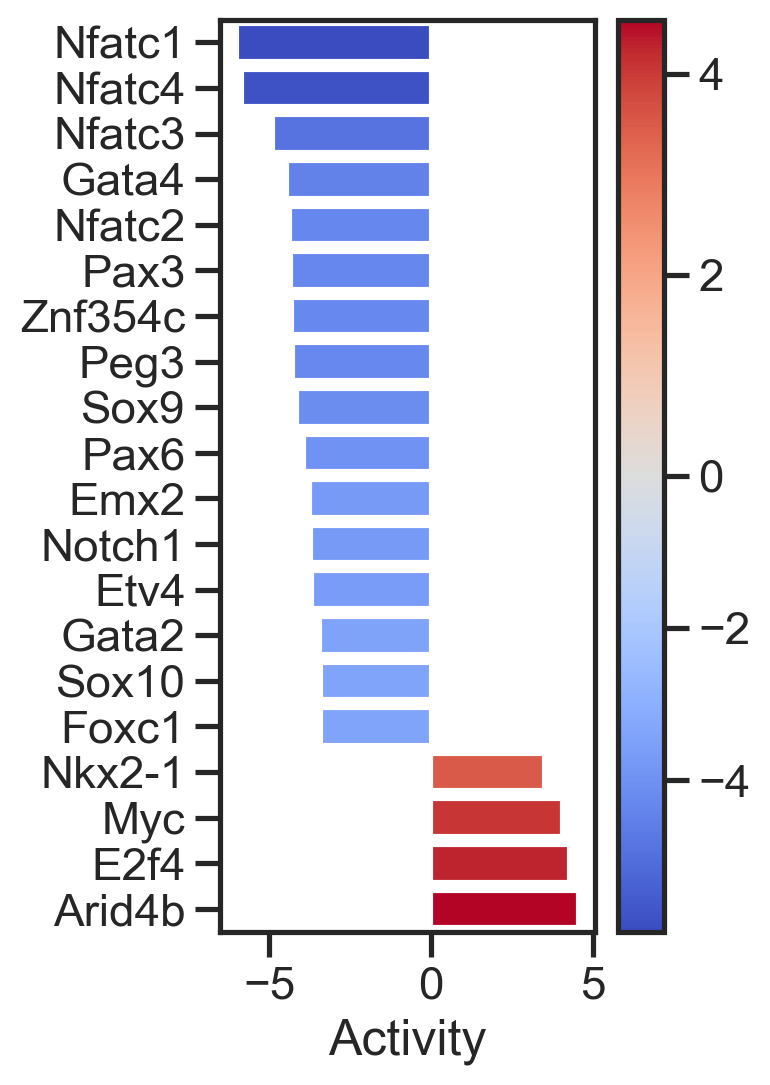

MES m_to_1


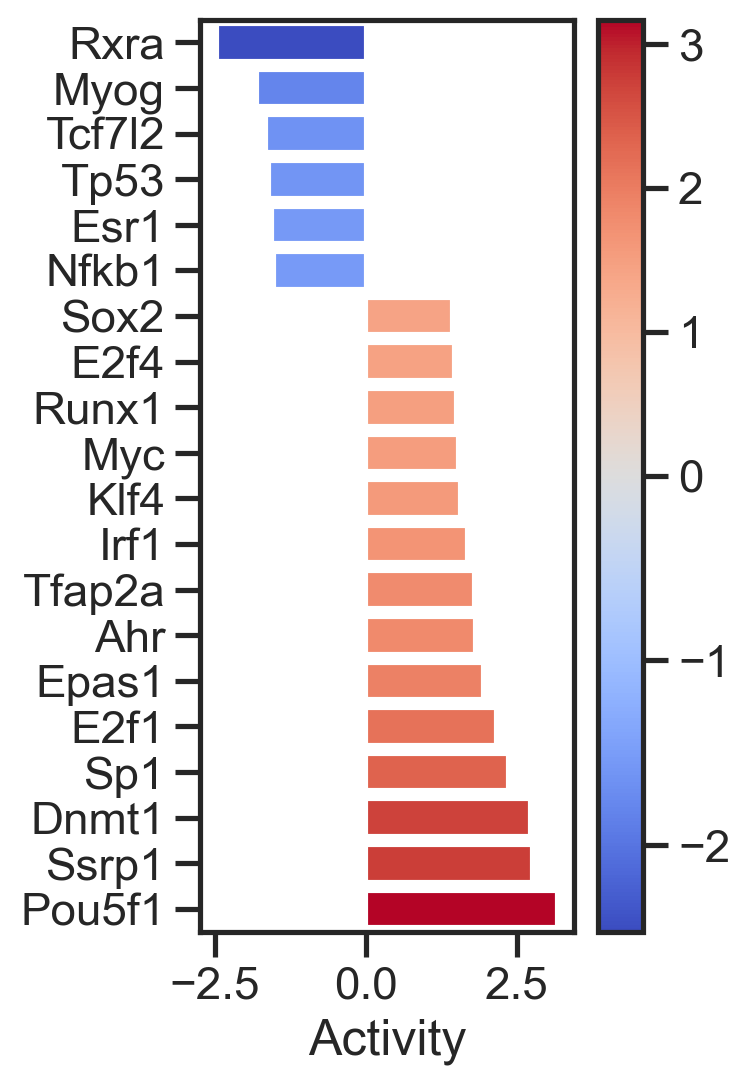

MES m_to_m


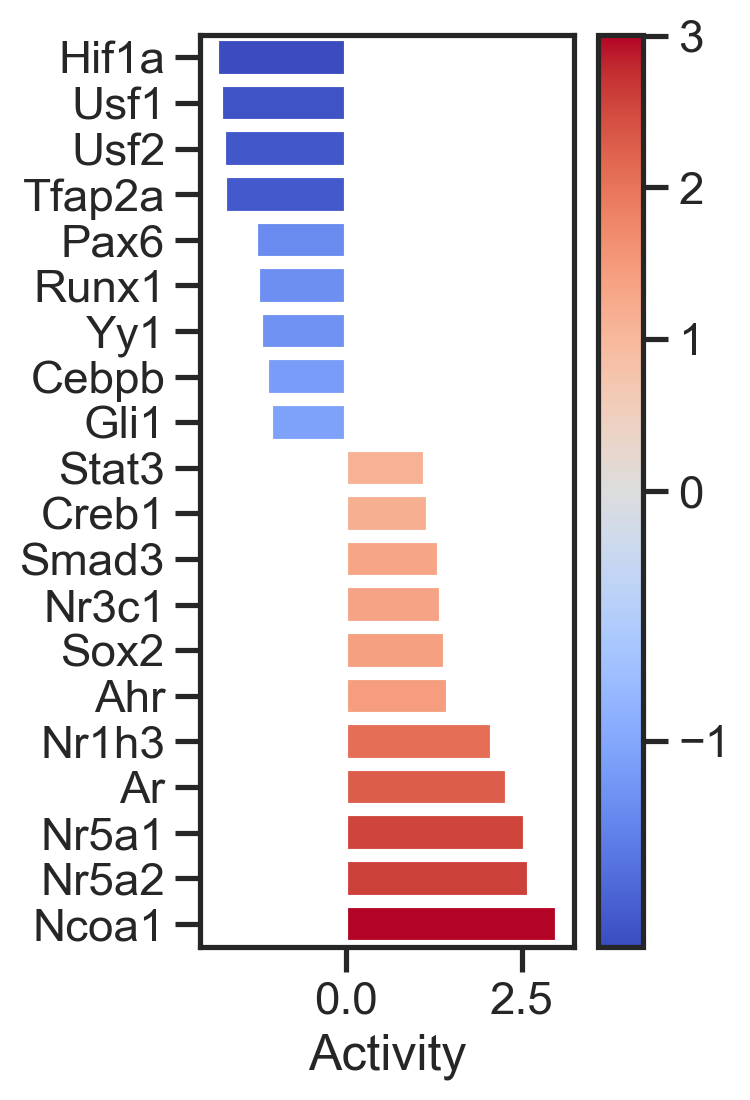

END 1_to_1


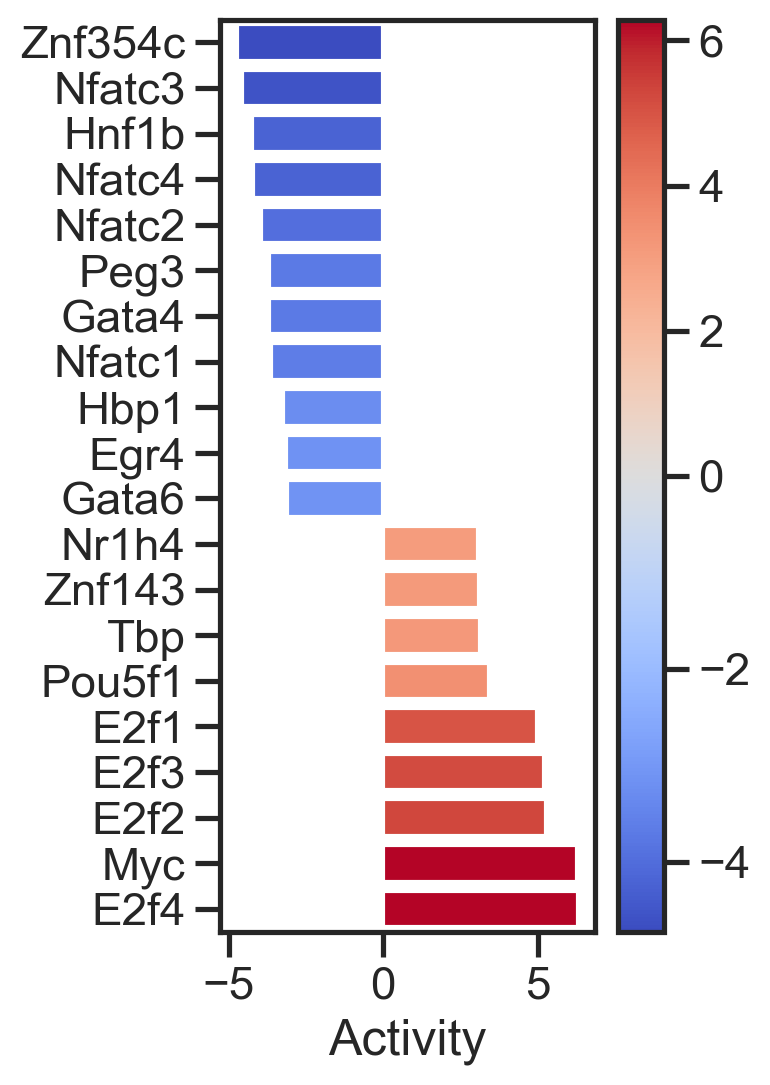

END m_to_1


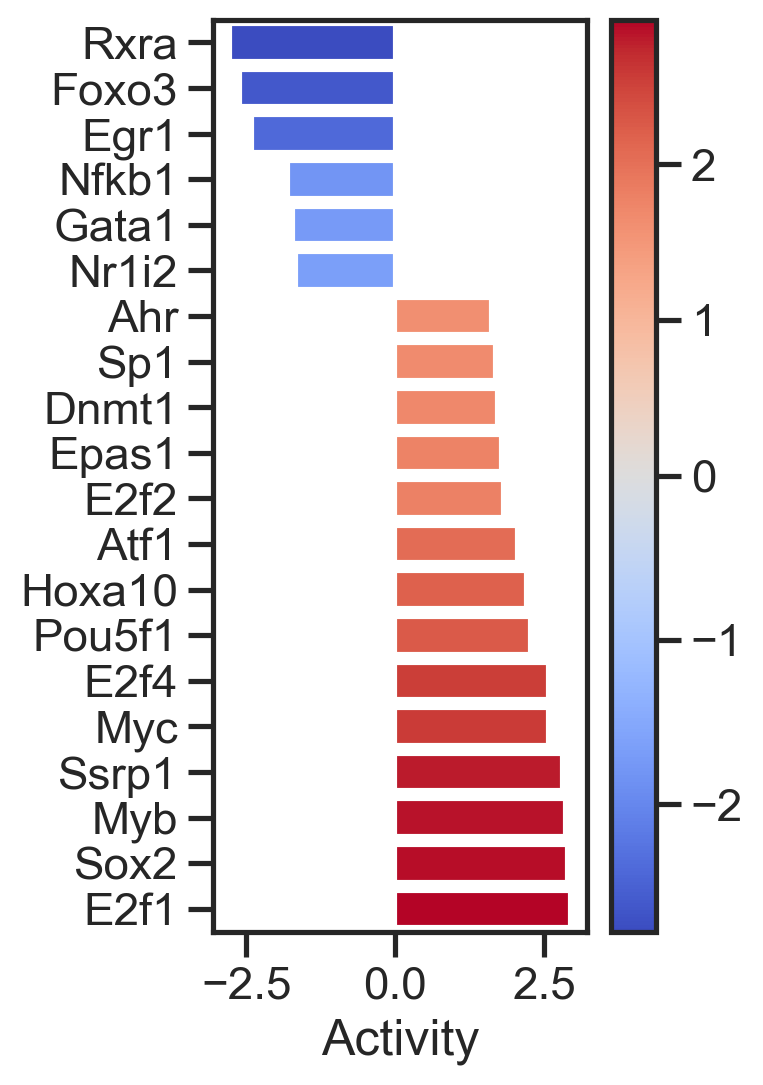

END m_to_m


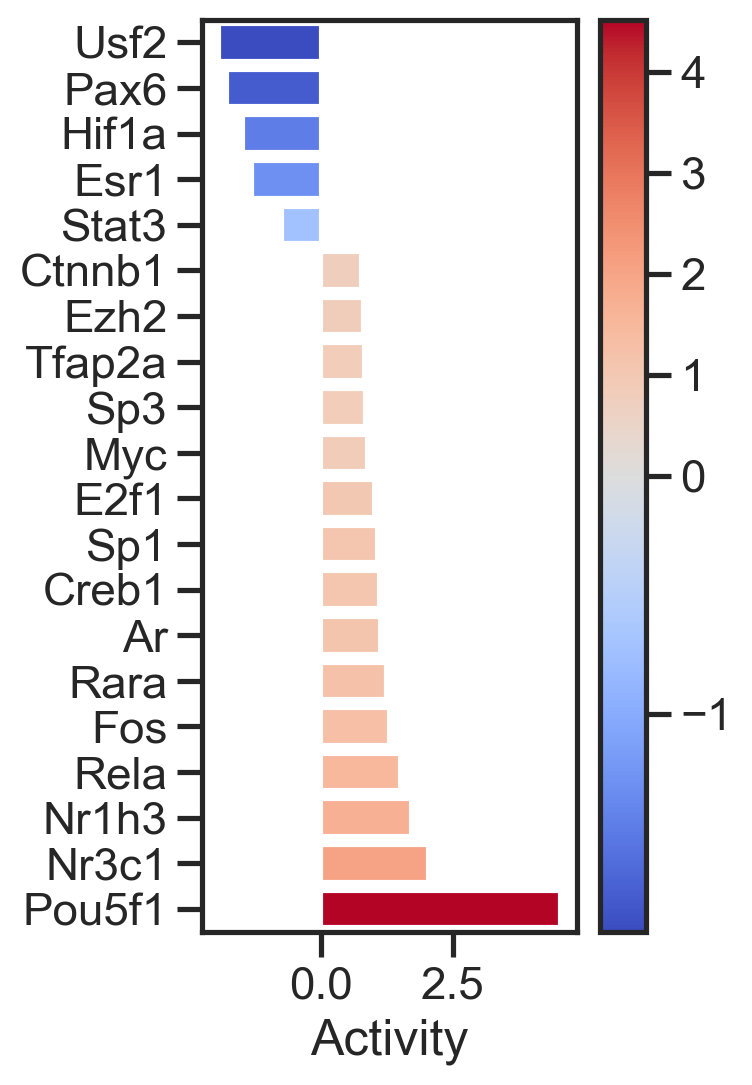

PLU 1_to_1


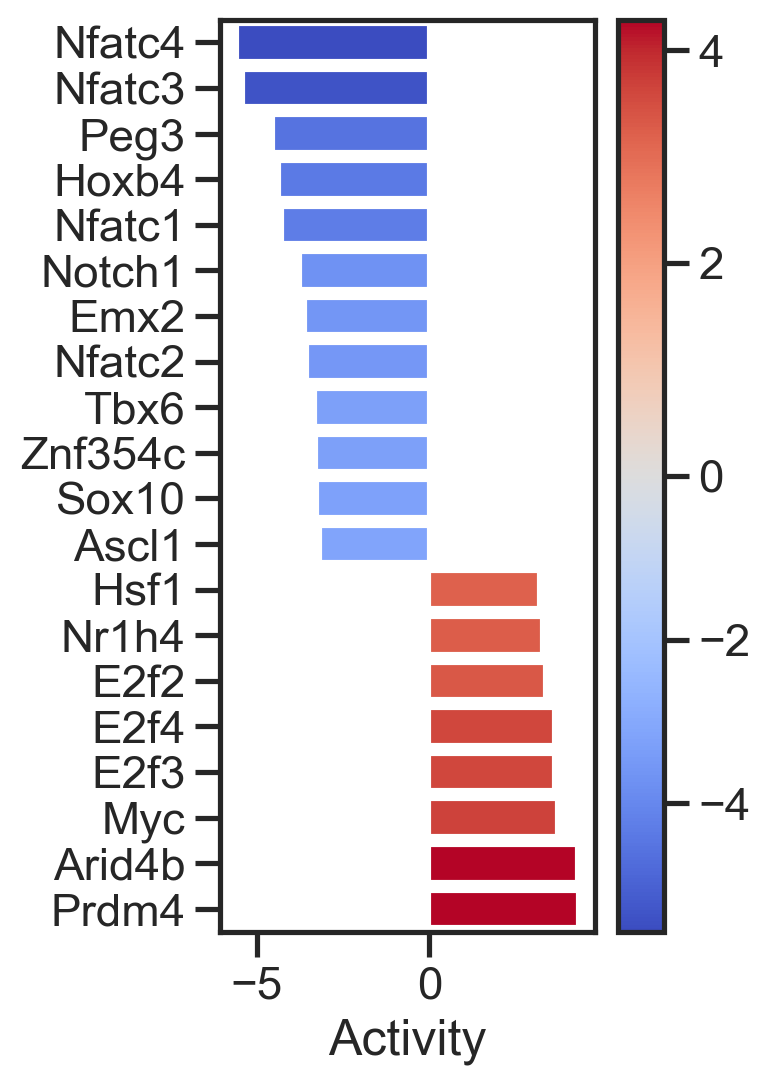

PLU m_to_1


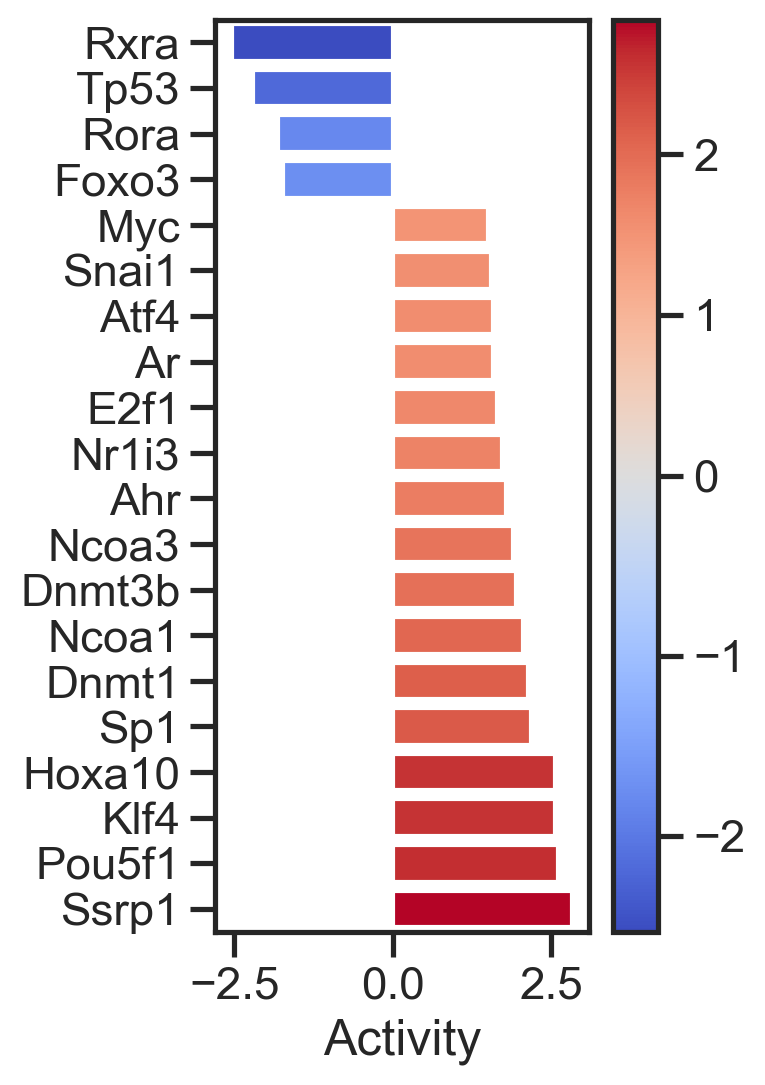

PLU m_to_m


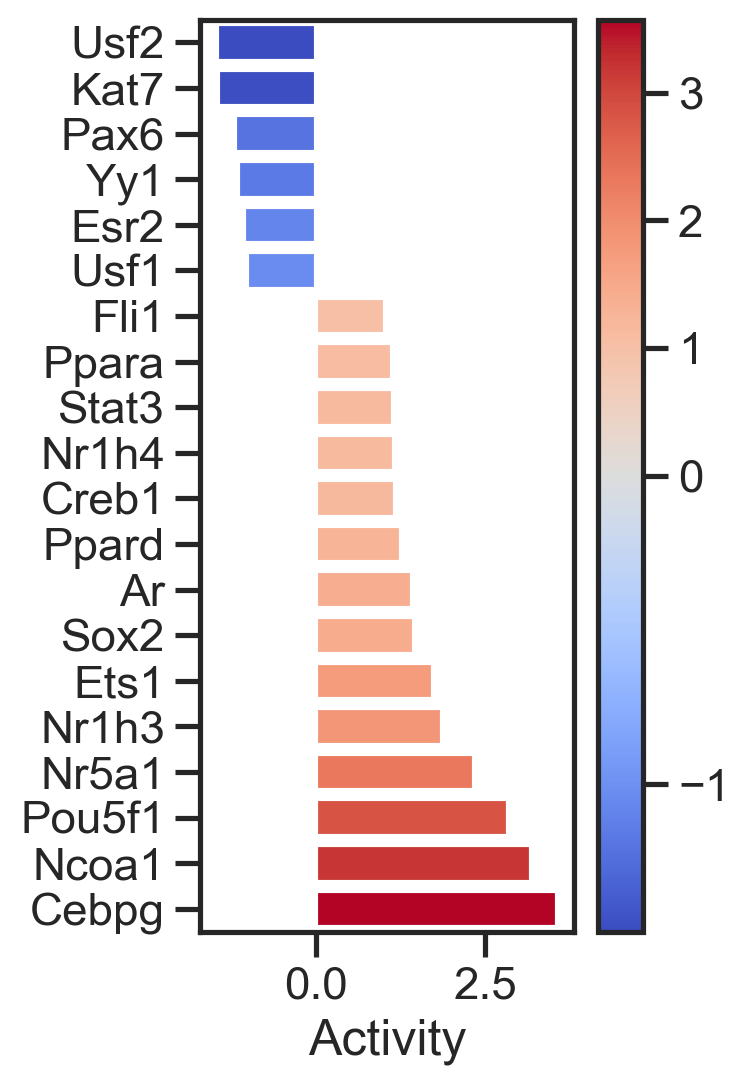

In [61]:
makeTFplots(results_df_ect,'ECT')
makeTFplots(results_df_mes,'MES')
makeTFplots(results_df_end,'END')
makeTFplots(results_df_plu,'PLU')

## pathway inference

PROGENy is a comprehensive resource containing a curated collection of pathways and their target genes, with weights for each interaction.\
Here is a brief description of each pathway:

- Androgen: involved in the growth and development of the male reproductive organs.
- EGFR: regulates growth, survival, migration, apoptosis, proliferation, and differentiation in mammalian cells
- Estrogen: promotes the growth and development of the female reproductive organs.
- Hypoxia: promotes angiogenesis and metabolic reprogramming when O2 levels are low.
- JAK-STAT: involved in immunity, cell division, cell death, and tumor formation.
- MAPK: integrates external signals and promotes cell growth and proliferation.
- NFkB: regulates immune response, cytokine production and cell survival.
- p53: regulates cell cycle, apoptosis, DNA repair and tumor suppression.
- PI3K: promotes growth and proliferation.
- TGFb: involved in development, homeostasis, and repair of most tissues.
- TNFa: mediates haematopoiesis, immune surveillance, tumour regression and protection from infection.
- Trail: induces apoptosis.
- VEGF: mediates angiogenesis, vascular permeability, and cell migration.
- WNT: regulates organ morphogenesis during development and tissue repair.

In [211]:
progeny = dc.get_progeny(organism='human', top=500)
progeny

,source,target,weight,p_value
0,Androgen,TMPRSS2,11.490631,0.000000e+00
1,Androgen,NKX3-1,10.622551,2.242078e-44
2,Androgen,MBOAT2,10.472733,4.624285e-44
3,Androgen,KLK2,10.176186,1.944414e-40
4,Androgen,SARG,11.386852,2.790209e-40
...,...,...,...,...
6995,p53,ZMYM4,-2.325752,1.522388e-06
6996,p53,CFDP1,-1.628168,1.526045e-06
6997,p53,VPS37D,2.309503,1.537098e-06
6998,p53,TEDC1,-2.274823,1.547037e-06


In [212]:
import pybiomart

In [213]:
from pybiomart import Dataset

dataset = Dataset(name='hsapiens_gene_ensembl',
                  host='http://www.ensembl.org')

convert = dataset.query(attributes=['ensembl_gene_id','external_gene_name',
                           'mmusculus_homolog_ensembl_gene',
                           'mmusculus_homolog_associated_gene_name'])

In [214]:
h2m=convert.loc[:,['Gene name', 'Mouse gene name']]
h2m=h2m.dropna()
mouse2human_mapping=dict(zip(h2m['Gene name'], h2m['Mouse gene name']))

In [215]:
mouse_genes_shared=np.intersect1d(progeny['target'], list(mouse2human_mapping.keys()))

#mouse_genes_mapped_to_human=[mouse2human_mapping[i] for i in mouse_genes_shared]

In [216]:
progeny = progeny[progeny['target'].isin(mouse_genes_shared)]
progeny = progeny.rename(columns={'target':'human'})
progeny['target'] = [mouse2human_mapping[i] for i in progeny['human']]

In [217]:
progeny = progeny.drop(columns='human')

In [218]:
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2', 'diffx', 'diffx2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'um

In [219]:
progeny = progeny[~progeny.duplicated(['source', 'target'])]#.sum()

In [220]:
progeny

,source,weight,p_value,target
0,Androgen,11.490631,0.000000e+00,Tmprss2
1,Androgen,10.622551,2.242078e-44,Nkx3-1
2,Androgen,10.472733,4.624285e-44,Mboat2
5,Androgen,7.363805,1.253072e-39,Slc38a4
6,Androgen,6.130646,2.534403e-38,Mtmr9
...,...,...,...,...
6995,p53,-2.325752,1.522388e-06,Zmym4
6996,p53,-1.628168,1.526045e-06,Cfdp1
6997,p53,2.309503,1.537098e-06,Vps37d
6998,p53,-2.274823,1.547037e-06,Tedc1


In [221]:
dc.run_mlm(
    mat=adata,
    net=progeny,
    source='source',
    target='target',
    weight='weight',
    verbose=True
)

357 features of mat are empty, they will be removed.
Running mlm on mat with 38117 samples and 43334 targets for 14 sources.


100%|██████████████████████████████████████████████████████████████████████████████████| 4/4 [01:48<00:00, 27.01s/it]


In [222]:
adata.obsm['mlm_estimate']

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_341,2.919806,-1.410098,1.192267,4.035650,-0.775352,3.867569,-0.555651,1.916719,6.764449,0.464893,-9.143122,1.915943,-2.197277,-1.822508
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_310,1.582614,-2.753338,3.308647,1.509103,-0.581359,12.513276,-0.806118,2.568042,5.176096,-0.080381,-14.429019,2.681548,-0.299096,-6.264976
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_302,2.536685,-2.243694,-0.109967,8.172015,-0.064761,5.562008,0.196682,-0.337939,6.848002,-0.988514,-9.169180,-1.374888,-1.668043,0.527882
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_5,1.304470,-1.350380,3.111361,1.504657,-0.479931,8.689500,-1.846737,0.228491,4.803716,0.950028,-12.767517,2.159260,-0.484746,-5.599801
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_184,0.683386,-1.412640,1.472703,0.719637,-1.306569,6.051422,-0.462723,0.539134,4.844940,-0.248949,-7.831231,1.455664,0.450065,-5.610999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PZ-MB-TChIC-Gastd7-rep3-H3K4me3-6_224,1.179422,0.256284,0.905475,4.465500,-0.845630,1.967515,-0.259449,0.163883,3.301802,0.153886,-6.954642,-2.798482,-0.420820,2.223111
PZ-MB-TChIC-Gastd7-rep3-H3K4me3-6_236,1.452075,-1.748150,-0.769862,7.166705,-0.845933,0.257679,0.356688,0.708386,3.099106,-1.070408,-6.771753,0.432208,-1.258633,0.131341
PZ-MB-TChIC-Gastd7-rep3-H3K4me3-6_199,0.580916,-1.877521,0.604654,4.089711,-1.641812,0.982477,-0.453112,3.266586,4.409188,0.448494,-4.676614,-2.425915,-1.781953,1.357395
PZ-MB-TChIC-Gastd7-rep3-H3K4me3-6_32,2.240768,-3.455495,1.899376,2.894047,-1.422415,1.436801,-0.282555,2.562982,4.116565,-0.218912,-11.271826,1.118554,-0.553575,-1.689482


In [223]:
adata.obsm['progeny_mlm_estimate'] = adata.obsm['mlm_estimate'].copy()
adata.obsm['progeny_mlm_pvals'] = adata.obsm['mlm_pvals'].copy()
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2', 'diffx', 'diffx2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'um

In [224]:
acts = dc.get_acts(adata, obsm_key='mlm_estimate')
acts

AnnData object with n_obs × n_vars = 38117 × 14
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2', 'diffx', 'diffx2'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_params', 'diffx_colors', 'diffx2_colors', 'dendrogram_celltype'
    obsm: 'X_pca', 'X_umap', 'mlm_estimate', 'mlm_pvals', 'progeny_mlm_estimate', 'progeny_mlm_pvals'

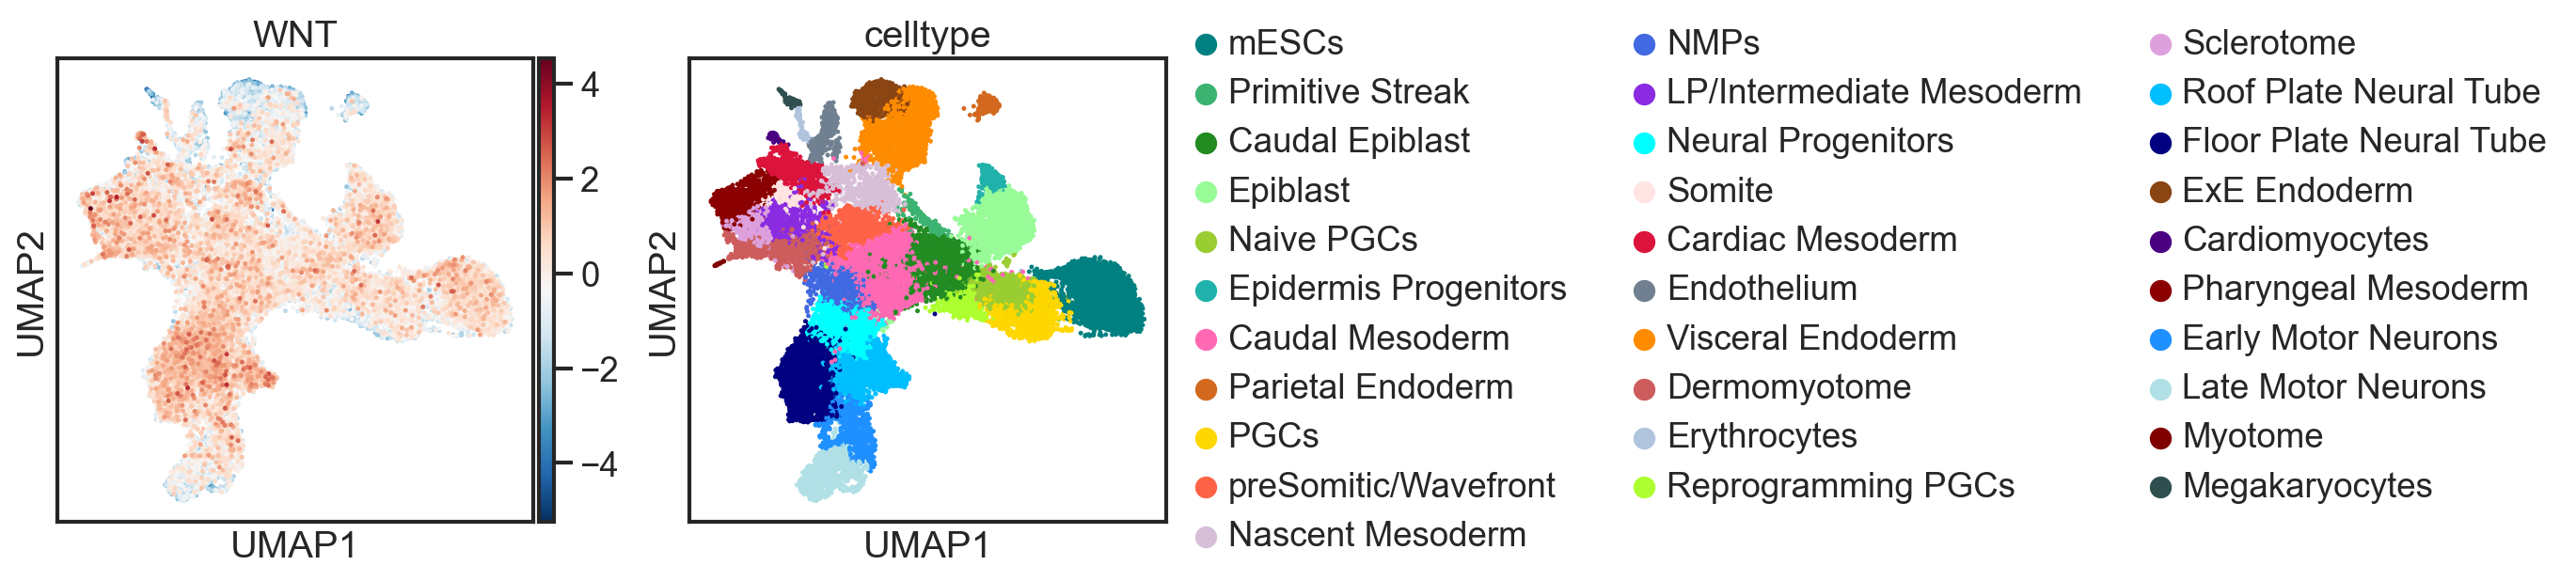

In [225]:
sc.pl.umap(acts, color=['WNT', 'celltype'], cmap='RdBu_r', size = 20)

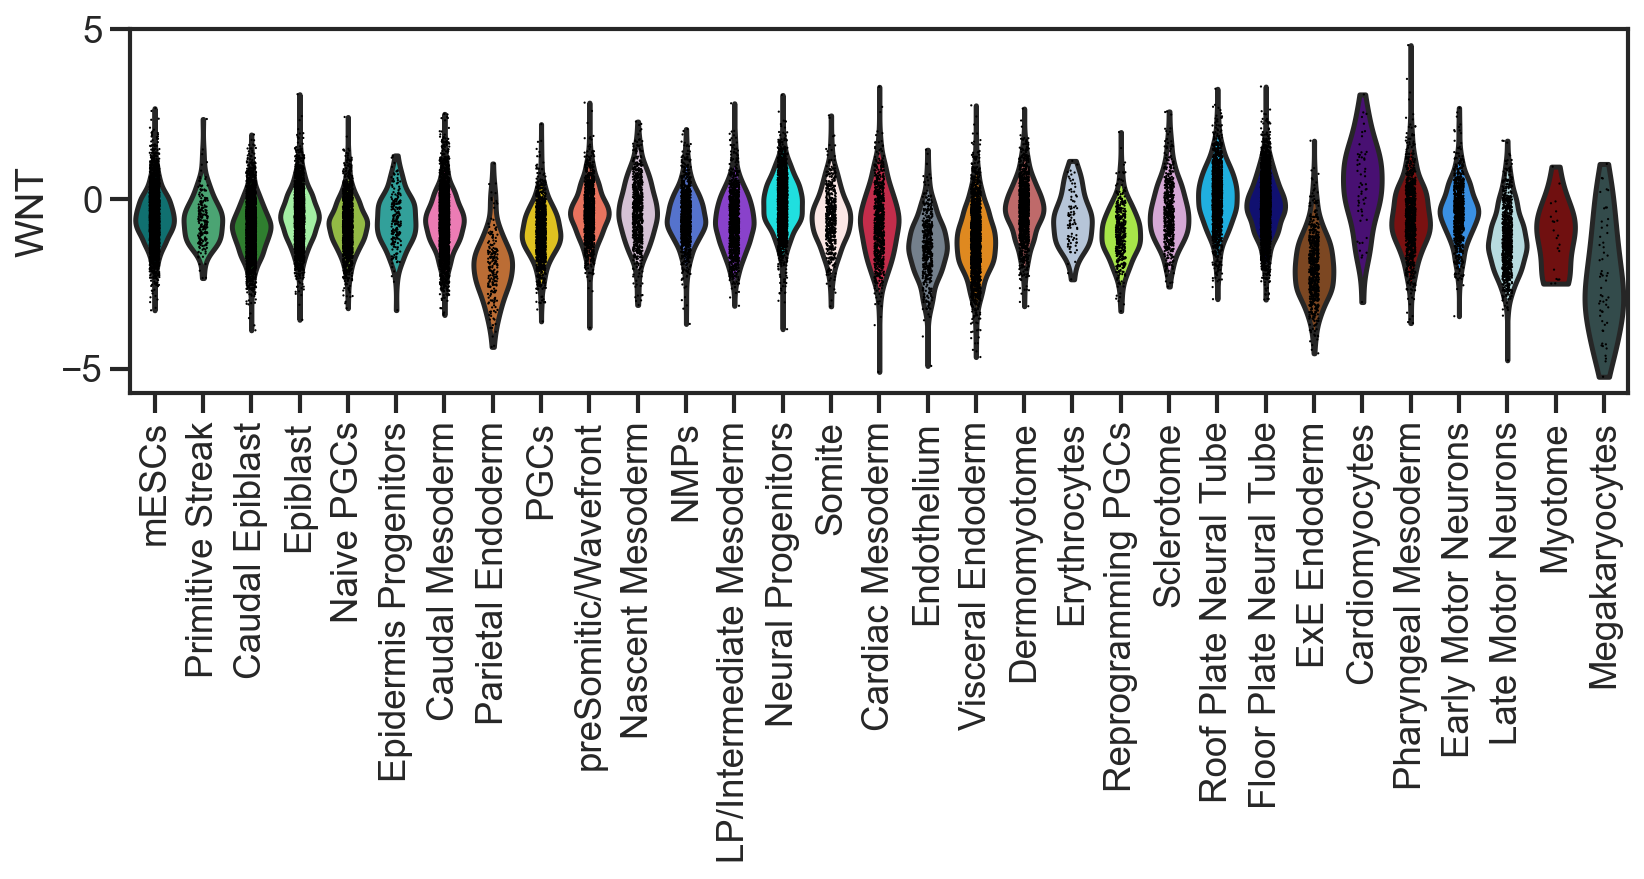

In [226]:
fig,ax=plt.subplots(figsize=(12,3))
sc.pl.violin(acts, keys=['WNT'], groupby='celltype', rotation=90,ax=ax, cols = adata.uns['celltype_colors'], order = adata.obs['celltype'].cat.categories)

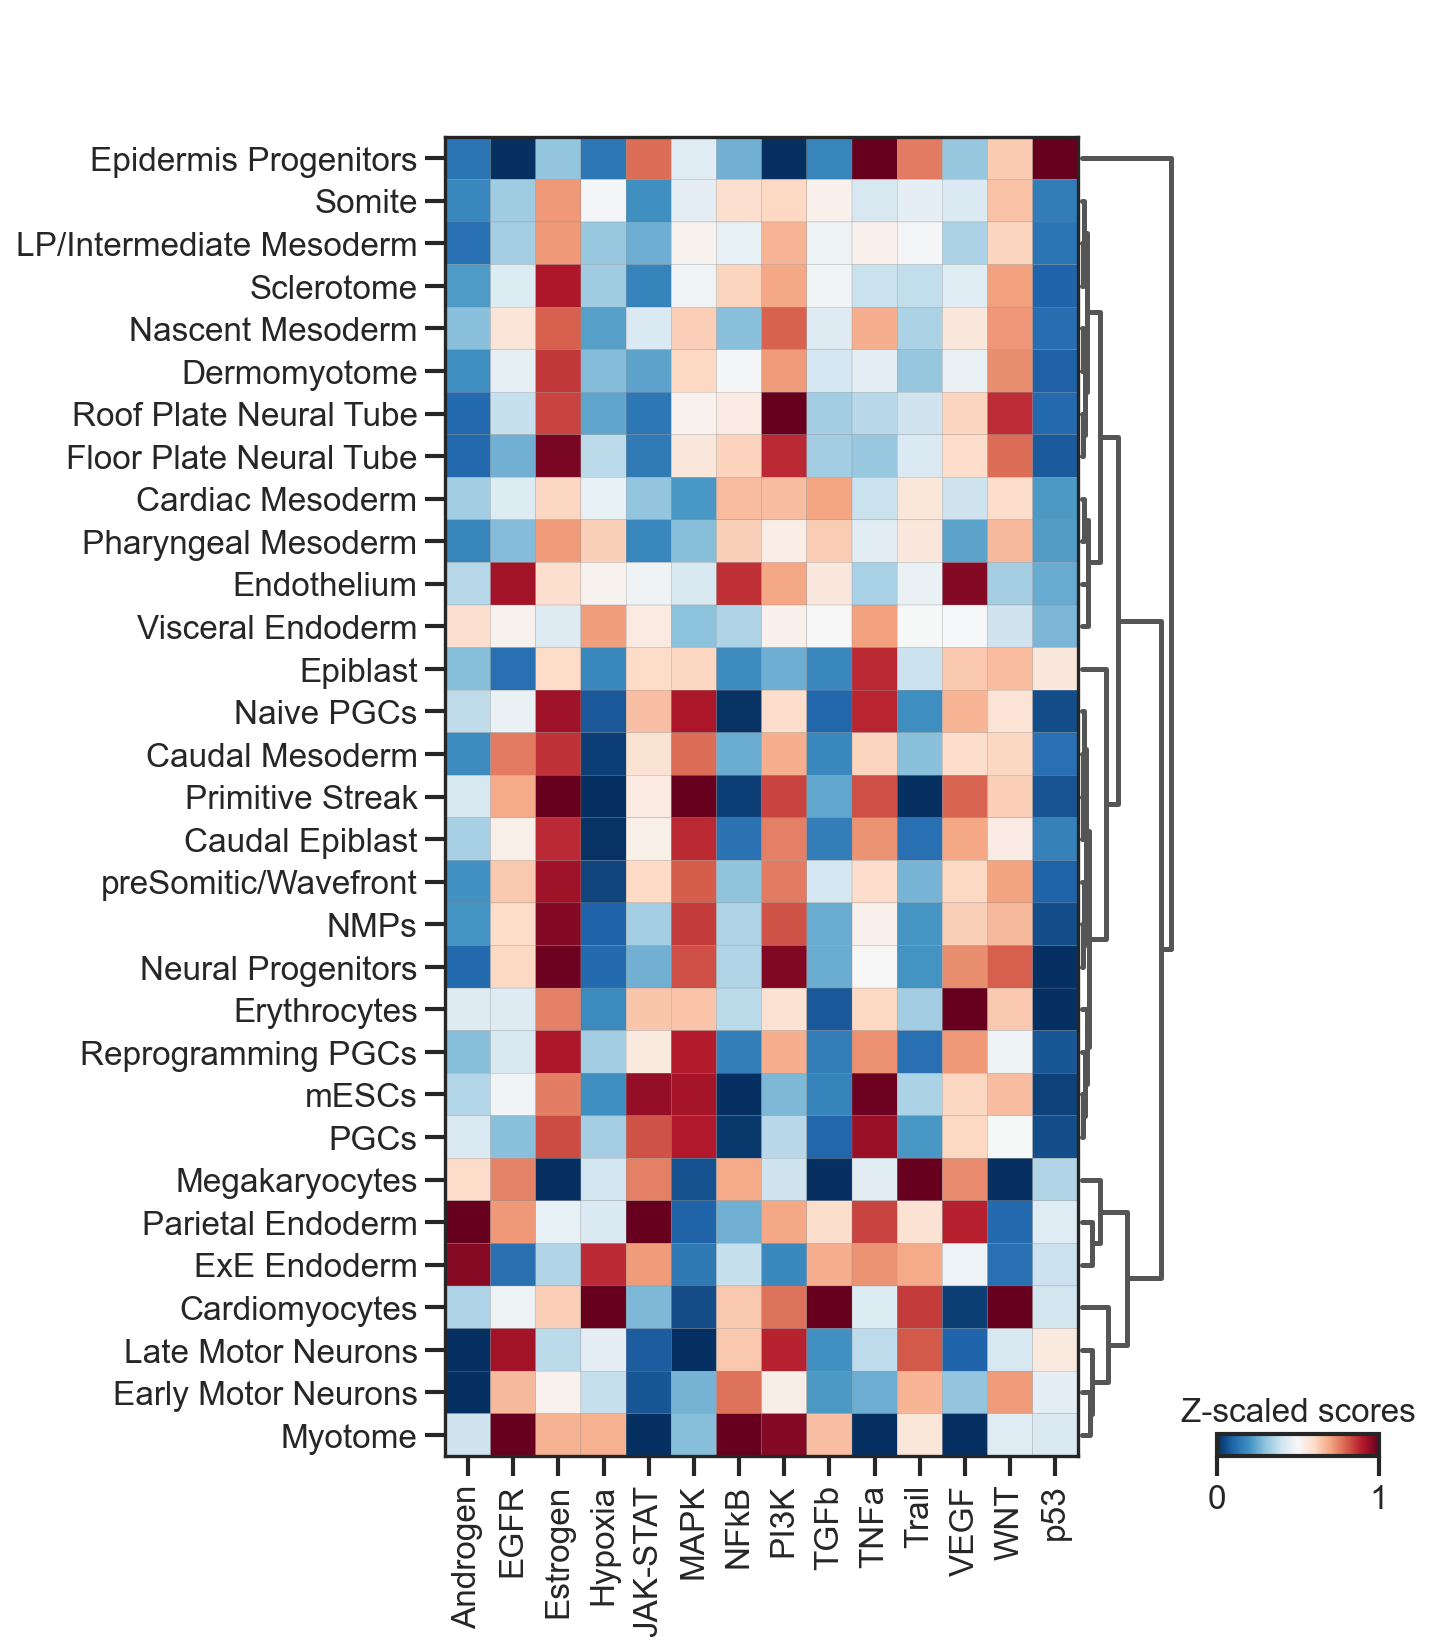

In [227]:
sc.pl.matrixplot(acts, var_names=acts.var_names, groupby='celltype', dendrogram=True, standard_scale='var',
                 colorbar_title='Z-scaled scores', cmap='RdBu_r')

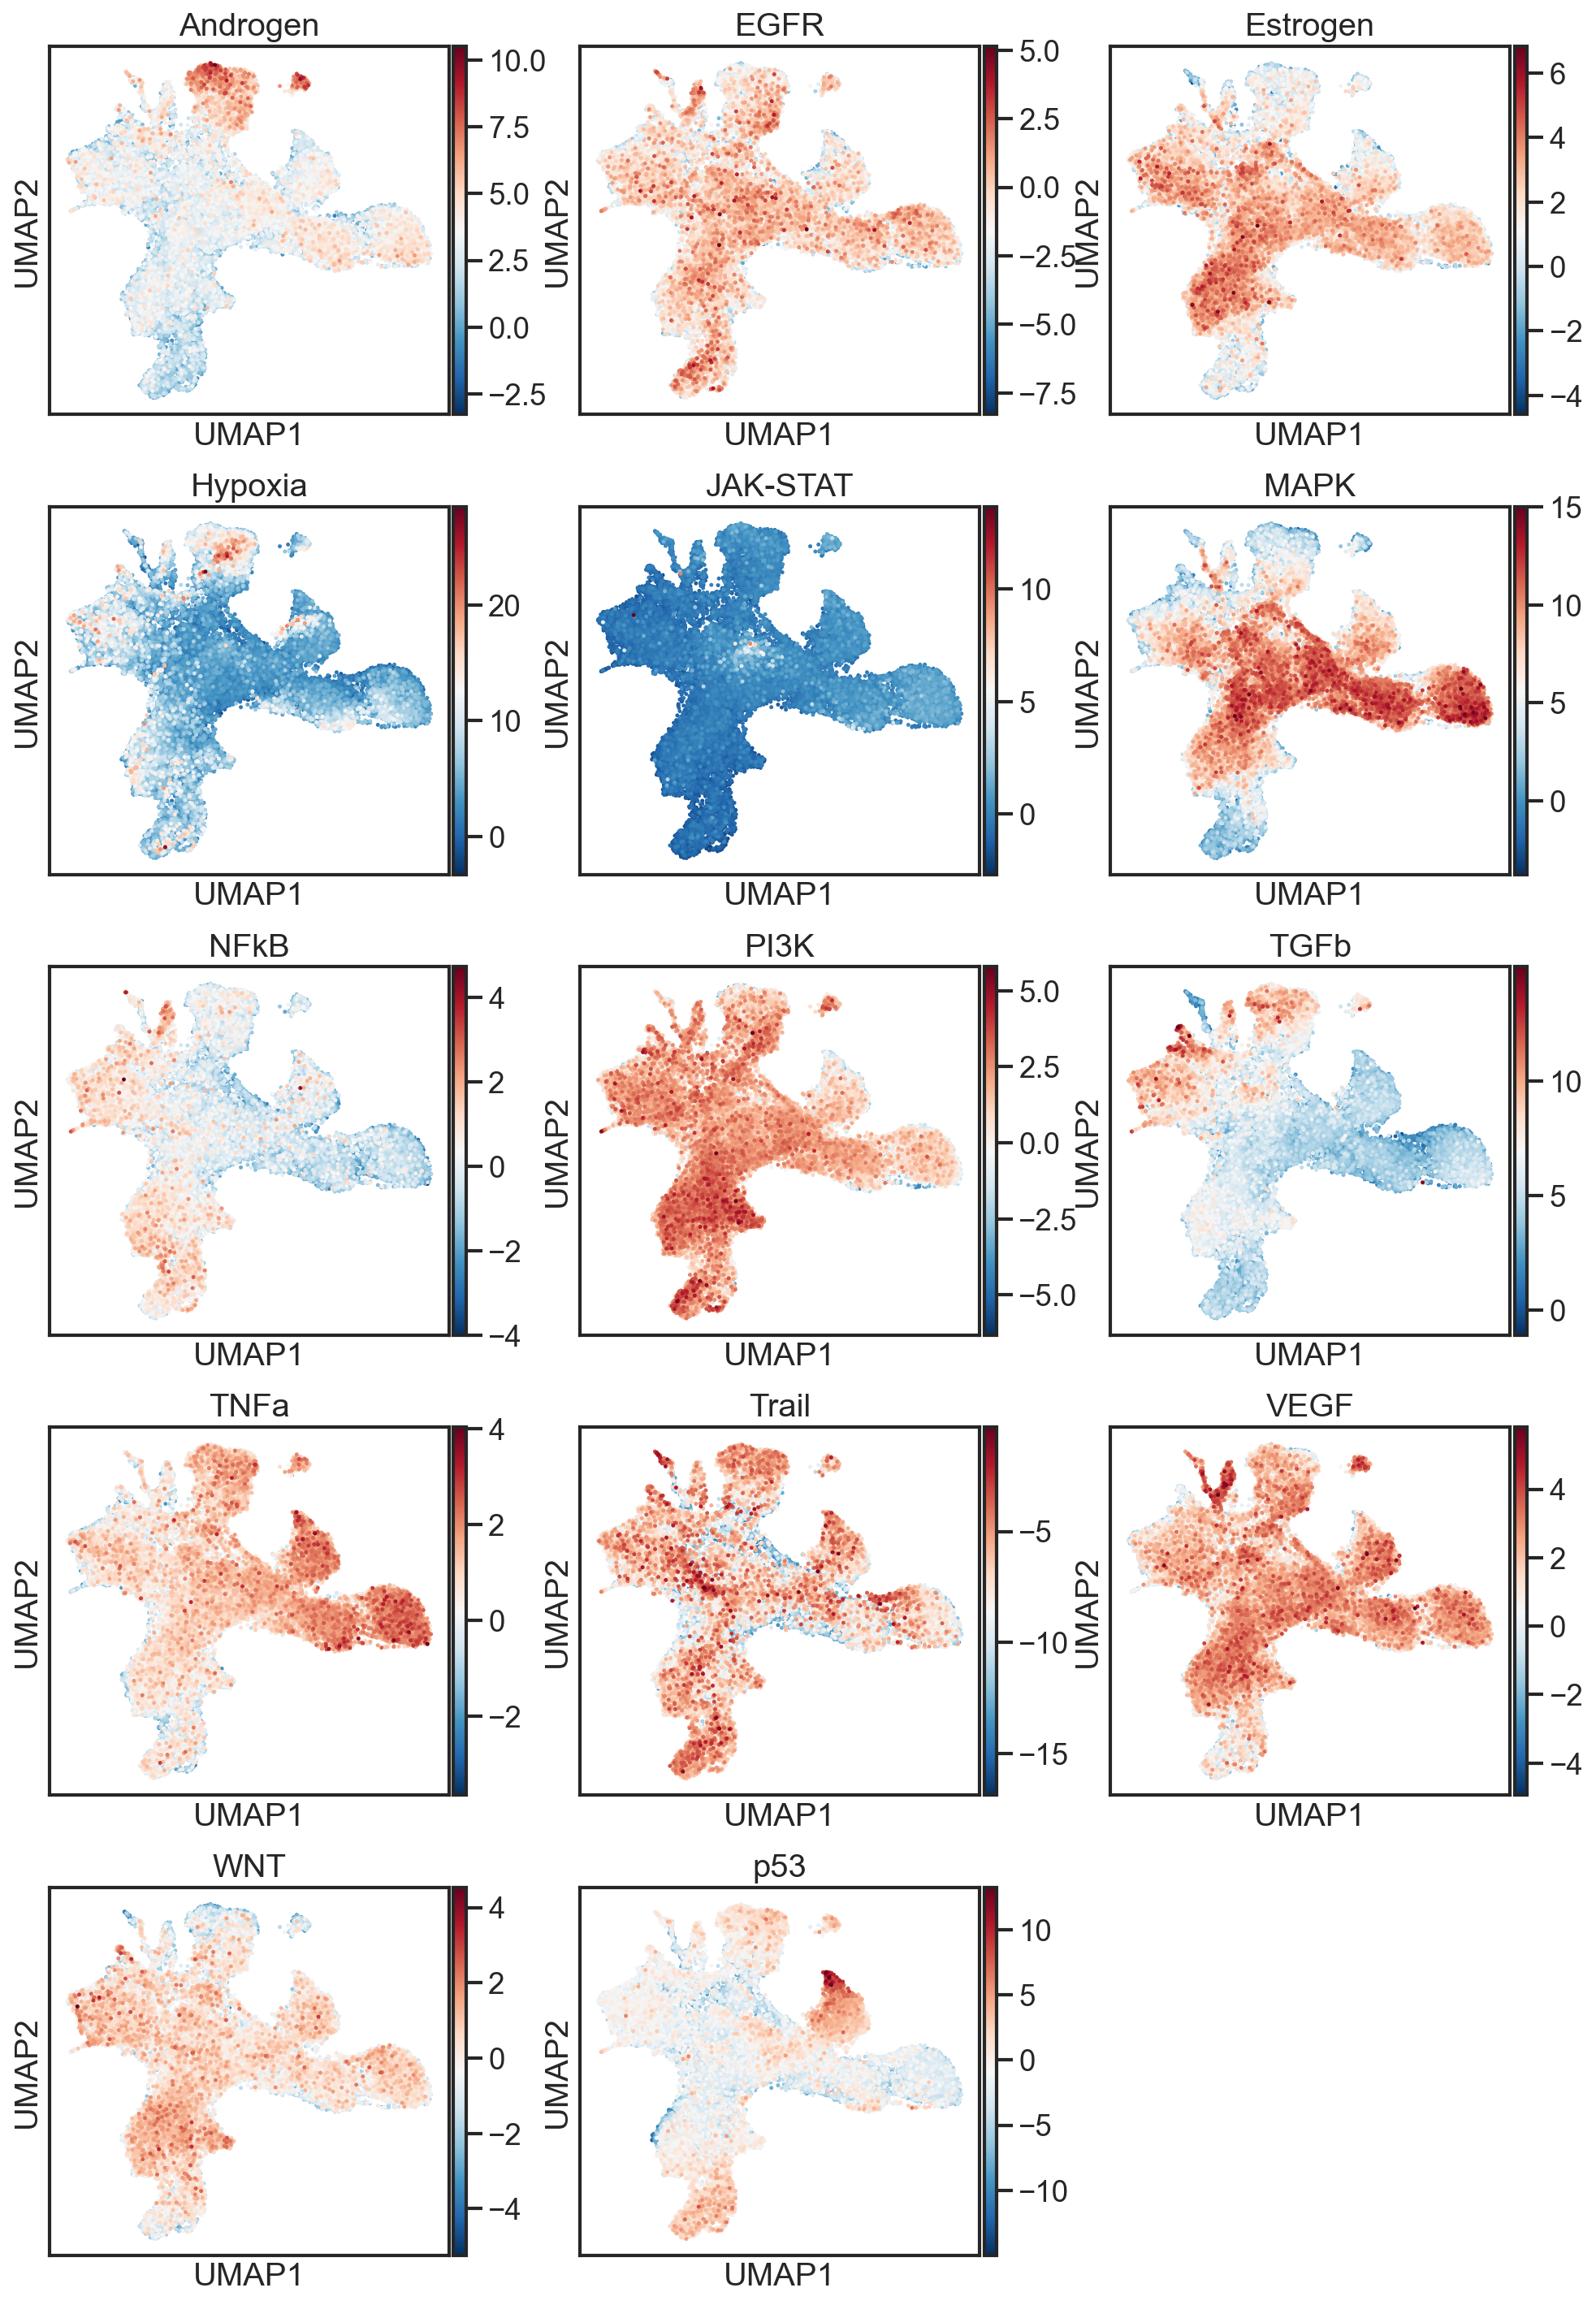

In [228]:
sc.pl.umap(acts, color=acts.var.index, cmap='RdBu_r', size = 20, ncols = 3)